# Ceridwen photometry and stellar spectroscopy fit

- Compare native-spectrum and integrated stellar-index likelihoods.


## Setup

- Kernel name is the same locally and on vastai.
- There is a short test to ensure the notebook runs
- There is also a short script with 5000 calls to benchmark likelihood call speed

In [1]:
import os
import sys
from datetime import UTC, datetime
from itertools import pairwise
from pathlib import Path

os.environ["JAX_ENABLE_X64"] = "1"

import astropy.units as u
from astropy.constants import c as C_LIGHT
import corner
import h5py
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
from astropy.table import Table
from ceridwen.cosmology import age_gyr, flux_factor_maggies
from ceridwen.csp import CSPBasis_afe
from ceridwen.fit import load_result_h5, write_result_h5
from ceridwen.likelihood import (
    DiagonalGaussianLikelihood,
    DiagonalNoiseModel,
    MultiObservationLikelihood,
    PolynomialCalibration,
)
from ceridwen.model import SedModel, logsfr_ratios_to_sfh
from ceridwen.observation import (
    LEGAC_DR2_STELLAR_INDEX_DEFINITIONS,
    Photometry,
    Spectrum,
    StellarIndices,
)
from ceridwen.sampler import run_sampler
from ceridwen.observation.absorption_features import absorption_feature_mask
from ceridwen.sampler.nested import BlackJAXNestedSamplerAdapter
from ceridwen.sampler.priors import ClippedNormal, StudentT, Uniform
from ceridwen.ssps import SSPDataAfe, fetch_grid
from scipy.special import softmax
from scipy.stats import entropy
from specutils.utils.wcs_utils import air_to_vac

jax.config.update("jax_enable_x64", True)
JAX_DEVICES = jax.devices()
GPU_AVAILABLE = any(device.platform == "gpu" for device in JAX_DEVICES) # true if any gpu is available
EXPECT_SINGLE_GPU = os.environ.get("CERIDWEN_EXPECT_SINGLE_GPU") == "1"
if EXPECT_SINGLE_GPU and (
    len(JAX_DEVICES) != 1 or JAX_DEVICES[0].platform != "gpu"
):
    raise RuntimeError(f"Expected one pinned GPU, found {JAX_DEVICES}")

FIT_MODES = {"full_spectrum", "stellar_indices"}
FIT_MODE = os.environ.get("CERIDWEN_FIT_MODE", "full_spectrum")
if FIT_MODE not in FIT_MODES:
    raise ValueError(f"CERIDWEN_FIT_MODE must be one of {sorted(FIT_MODES)}")
TARGET_ID = os.environ.get("CERIDWEN_TARGET_ID", "M1_210210")
OBJECT_ID = int(os.environ.get("CERIDWEN_OBJECT_ID", TARGET_ID.split("_")[-1]))
MANIFEST_INDEX = int(os.environ.get("CERIDWEN_MANIFEST_INDEX", "0"))
SEED = int(os.environ.get("CERIDWEN_RANDOM_SEED", "20260812"))
QUICK_TEST = os.environ.get("CERIDWEN_NOTEBOOK_QUICK") == "1" # checks env variable to decide on fast vs full run
SPECTRUM_PIXEL_MODES = {"all", "features", "features_downweight"}
SPECTRUM_PIXELS = os.environ.get("CERIDWEN_SPECTRUM_PIXELS", "all")
if SPECTRUM_PIXELS not in SPECTRUM_PIXEL_MODES:
    raise ValueError(
        f"CERIDWEN_SPECTRUM_PIXELS must be one of {sorted(SPECTRUM_PIXEL_MODES)}"
    )
FEATURE_WINDOW_KMS = float(os.environ.get("CERIDWEN_FEATURE_WINDOW_KMS", "1000"))
FEATURE_DOWNWEIGHT = os.environ.get("CERIDWEN_FEATURE_DOWNWEIGHT", "balance")
MOCK_TRUTH_PATH = os.environ.get("CERIDWEN_MOCK_TRUTH")
MOCK_SEED = int(os.environ.get("CERIDWEN_MOCK_SEED", "0"))
MOCK_TILT = float(os.environ.get("CERIDWEN_MOCK_TILT", "0"))
MOCK_SNR_SCALE = float(os.environ.get("CERIDWEN_MOCK_SNR_SCALE", "1"))
# Chebyshev calibration polynomial of the model spectrum: order 0 switches it off.
CALIBRATION_ORDER = int(os.environ.get("CERIDWEN_CALIBRATION_ORDER", "3"))
CALIBRATION_PRIOR_SIGMA = float(os.environ.get("CERIDWEN_CALIBRATION_PRIOR", "0.1"))
# Free redshift and free LOSVD: 0 keeps both fixed at the catalogue values.
FREE_ZRED_KMS = float(os.environ.get("CERIDWEN_FREE_ZRED_KMS", "0"))
FREE_SIGMA_FRAC = float(os.environ.get("CERIDWEN_FREE_SIGMA_FRAC", "0"))
assert FREE_ZRED_KMS >= 0.0 and FREE_SIGMA_FRAC >= 0.0
assert (FREE_ZRED_KMS == 0.0 and FREE_SIGMA_FRAC == 0.0) or FIT_MODE == "full_spectrum"
# Fit-accuracy knobs; every default is the production poly3_total setting.
FCALIB_MAX = float(os.environ.get("CERIDWEN_FCALIB_MAX", "0.10"))
EMISSION_LINES = [
    float(value)
    for value in os.environ.get(
        "CERIDWEN_EMISSION_LINES", "3726.0,3728.8,4861.3,4958.9,5006.8"
    ).split(",")
]
PHOT_DROP = [name for name in os.environ.get("CERIDWEN_PHOT_DROP", "").split(",") if name]
FREE_DUST_INDEX = os.environ.get("CERIDWEN_FREE_DUST_INDEX", "1") == "1"
SFH_PRIOR = os.environ.get("CERIDWEN_SFH_PRIOR", "student")
# Dust-column prior: "uniform" is Uniform(0, 2); "clipped" is Ceridwen's documented
# ClippedNormal(0.3, 1.0, 0, 4).
TAU_PRIOR = os.environ.get("CERIDWEN_TAU_PRIOR", "uniform")
# Uniform prior edges on the Kriek & Conroy slope; Prospector's alpha template uses -2.0,0.5.
DUST_INDEX_BOUNDS = tuple(
    float(edge) for edge in os.environ.get("CERIDWEN_DUST_INDEX_BOUNDS", "-1.0,0.4").split(",")
)
# Rest-frame windows "lo:hi,lo:hi" in Angstrom, masked after redshifting.
MASK_REST_WINDOWS = [
    tuple(float(edge) for edge in window.split(":"))
    for window in os.environ.get("CERIDWEN_MASK_REST_WINDOWS", "").split(",")
    if window
]
if SFH_PRIOR not in {"uniform", "student"}:
    raise ValueError("CERIDWEN_SFH_PRIOR must be 'uniform' or 'student'")
if TAU_PRIOR not in {"uniform", "clipped"}:
    raise ValueError("CERIDWEN_TAU_PRIOR must be 'uniform' or 'clipped'")
if len(DUST_INDEX_BOUNDS) != 2 or DUST_INDEX_BOUNDS[0] >= DUST_INDEX_BOUNDS[1]:
    raise ValueError("CERIDWEN_DUST_INDEX_BOUNDS must be 'low,high' with low < high")
if not 0.01 < FCALIB_MAX <= 1.0:
    raise ValueError("CERIDWEN_FCALIB_MAX must lie in (0.01, 1]")
C_KMS = float(C_LIGHT.to_value(u.km / u.s))
PHOTOMETRY_SOURCES = {"cosmos_ap3", "cosmos_total"}
PHOTOMETRY_SOURCE = os.environ.get("CERIDWEN_PHOTOMETRY", "cosmos_total")
if PHOTOMETRY_SOURCE not in PHOTOMETRY_SOURCES:
    raise ValueError(f"CERIDWEN_PHOTOMETRY must be one of {sorted(PHOTOMETRY_SOURCES)}")
if CALIBRATION_ORDER < 0:
    raise ValueError("CERIDWEN_CALIBRATION_ORDER must be >= 0")
if FIT_MODE != "full_spectrum" and (SPECTRUM_PIXELS != "all" or MOCK_TRUTH_PATH):
    raise ValueError("pixel selection and mock data need CERIDWEN_FIT_MODE=full_spectrum")
RUN_PROFILE = "quick" if QUICK_TEST else ("gpu-full" if GPU_AVAILABLE else "cpu-trial")
DEFAULT_PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", DEFAULT_PROJECT_ROOT))
RESULTS_ROOT = Path(os.environ.get("CERIDWEN_RESULTS_ROOT", PROJECT_ROOT / "results"))
RUN_ID = datetime.now(UTC).strftime("%Y%m%dT%H%M%SZ")
DEFAULT_RESULT_DIR = RESULTS_ROOT / (
    f"ceridwen_integrated_{FIT_MODE}_{RUN_PROFILE}_{RUN_ID}"
)
RESULT_DIR = Path(os.environ.get("CERIDWEN_RESULT_DIR", DEFAULT_RESULT_DIR))
RESULT_DIR.mkdir(parents=True, exist_ok=True)
print(f"target: {TARGET_ID}")
print(f"fit mode: {FIT_MODE}")
print(f"random seed: {SEED}")
print(f"JAX devices: {JAX_DEVICES}")
print(f"result directory: {RESULT_DIR}")
print(f"spectrum pixels: {SPECTRUM_PIXELS}")
print(f"photometry source: {PHOTOMETRY_SOURCE}")
print(f"free redshift: {'fixed' if FREE_ZRED_KMS == 0 else f'prior sigma {FREE_ZRED_KMS:.0f} km/s'}")
print(f"free sigma*: {'fixed' if FREE_SIGMA_FRAC == 0 else f'prior sigma {100 * FREE_SIGMA_FRAC:.0f}%'}")
print(
    "calibration polynomial: "
    + (f"Chebyshev order {CALIBRATION_ORDER}, prior sigma {CALIBRATION_PRIOR_SIGMA}, marginalised"
       if CALIBRATION_ORDER > 0 else "off (spectrum_scaling only)")
)
print(f"f_calib ceiling: {FCALIB_MAX:.2f}")
print(f"masked emission lines (rest A): {EMISSION_LINES}")
print(f"masked rest windows (A): {MASK_REST_WINDOWS}")
print(f"dropped photometric bands: {PHOT_DROP}")
print(f"dust index: {'free, Uniform(-1.0, 0.4)' if FREE_DUST_INDEX else 'fixed -0.7'}")
print(f"SFH prior on logsfr_ratios: {SFH_PRIOR}")
if SPECTRUM_PIXELS != "all":
    print(f"feature window: {FEATURE_WINDOW_KMS:.0f} km/s; downweight: {FEATURE_DOWNWEIGHT}")
if MOCK_TRUTH_PATH:
    print(f"mock truth: {MOCK_TRUTH_PATH} seed={MOCK_SEED} tilt={MOCK_TILT} snr_scale={MOCK_SNR_SCALE}")


target: M5_172669
fit mode: full_spectrum
random seed: 20261830
JAX devices: [CudaDevice(id=0)]
result directory: /workspace/cosmic-chronometers-jwst/results/fit-accuracy-knobs/new_default_rep1/172669-M5_172669
spectrum pixels: all
photometry source: cosmos_total
free redshift: fixed
free sigma*: fixed
calibration polynomial: Chebyshev order 3, prior sigma 0.1, marginalised
f_calib ceiling: 0.10
masked emission lines (rest A): [3726.0, 3728.8, 4861.3, 4958.9, 5006.8]
masked rest windows (A): []
dropped photometric bands: []
dust index: free, Uniform(-1.0, 0.4)
SFH prior on logsfr_ratios: student


## Data

- Read immutable LEGA-C and matched COSMOS2015 catalogues.
- Load the selected object's public one-dimensional spectrum.

In [2]:
LEGAC_PATH = PROJECT_ROOT / "data/raw/legac_dr2/legaCdr2.fits.gz"
PHOT_PATH = (
    PROJECT_ROOT / "data/raw/cosmos2015/cosmos2015_legac_dr2_photometry_1arcsec.fits"
)
SPECTRA_DIR = PROJECT_ROOT / "data/raw/legac_dr2/sp"

legac = Table.read(LEGAC_PATH) # loads data into astropy table
phot = Table.read(PHOT_PATH)

assert len(legac) == 1988
assert len(np.unique(phot["LEGAC_INDEX"])) == len(phot) # left -> number of distinct values in LEGAC_INDEX column
# verifies phot is unique
assert np.max(phot["MATCH_SEP_ARCSEC"]) < 1.0

## Passive selection

- Apply identical quality, NUVrJ, and emission-line filters.
- Require clean twelve-band photometry for joint fitting.

In [3]:
legac_frame = legac.to_pandas()
for text_column in ["SPECT_ID", "Filename"]:
    legac_frame[text_column] = legac_frame[text_column].map(
        lambda value: value.decode() if isinstance(value, bytes) else value
    )
phot_frame = phot.to_pandas().set_index("LEGAC_INDEX") # LEGAC_INDEX becomes the index column instead of data
phot_columns = [
    "Area",
    "Sat",
    "Cfl",
    "Deep",
    "Flag",
    "E(B-V)",
    "NUVMag",
    "RMag",
    "JMag",
    "Fuap3",
    "e_Fuap3",
    "FBap3",
    "e_FBap3",
    "FVap3",
    "e_FVap3",
    "Frap3",
    "e_Frap3",
    "Fipap3",
    "e_Fipap3",
    "Fzppap3",
    "e_Fzppap3",
    "FYap3",
    "e_FYap3",
    "FJap3",
    "e_FJap3",
    "FHap3",
    "e_FHap3",
    "FKsap3",
    "e_FKsap3",
    "F3.6um",
    "e_F3.6um",
    "F4.5um",
    "e_F4.5um",
]
parent = legac_frame.join(phot_frame[phot_columns], how="inner") #inner join of two dfs

quality = (
    (parent["f_use"] == 1)
    & (parent["f_ppxf"] == 0)
    & (parent["f_z"] == 0)
    & (parent["f_int"] == 0)
    & (parent["SN"] > 0)
    & (parent["z"] >= 0.6)
    & (parent["z"] < 1.0)
)
valid_rest_magnitudes = (parent[["NUVMag", "RMag", "JMag"]] > -40).all(axis=1) # check for
parent = parent[quality & valid_rest_magnitudes].copy()

nuv_r = parent["NUVMag"] - parent["RMag"]
r_j = parent["RMag"] - parent["JMag"] # pandas Series
nuvrj = (nuv_r > 3 * r_j + 1) & (nuv_r > 3.1) # mask
photometric_passive = parent[nuvrj]

oii_ew = photometric_passive["OII_3727_EW"]
weak_oii = photometric_passive[(oii_ew > -5) | oii_ew.isna()] # | is logical OR, mask produced inside [] brackets
oii_significance = (weak_oii["OII_3727_EW"] / weak_oii["OII_3727_EW_err"]).abs()
oiii_significance = (weak_oii["OIII_5007_EW"] / weak_oii["OIII_5007_EW_err"]).abs()
bona_fide_passive = weak_oii[~((oii_significance >= 3) | (oiii_significance >= 3))] # pick rows with weak OII/OIII S/N

clean_photometry = (                 #COSMOS2015 photometry flags
    (bona_fide_passive["Area"] == 0)  # inside UltraVISTA survey
    & (bona_fide_passive["Sat"] == 0) # not saturated
    & (bona_fide_passive["Cfl"] == 1) # inside COSMOS field
    & (bona_fide_passive["Flag"] == 0) # inside deep survey coverage
)
usable_passive = bona_fide_passive[clean_photometry].copy()
selected_passive = (
    usable_passive.sort_values(["SN", "SPECT_ID"], ascending=[False, True])
    .drop_duplicates("OBJECT", keep="first")
    .sort_values(["SN", "SPECT_ID"], ascending=[False, True])
)
assert len(usable_passive) == 194
assert len(selected_passive) == 187

selection_counts = pd.DataFrame(
    {"count": {
        "matched primary spectra": len(parent),
        "NUVrJ passive": len(photometric_passive),
        "weak [OII]": len(weak_oii),
        "bona-fide passive": len(bona_fide_passive),
        "clean twelve-band photometry": len(usable_passive),
        "unique objects, highest S/N": len(selected_passive),
    }}
)
display(selection_counts)

,count
matched primary spectra,1328
NUVrJ passive,609
weak [OII],454
bona-fide passive,349
clean twelve-band photometry,194
"unique objects, highest S/N",187


## Shared target

- Select one LEGA-C target; default to M1_210210.
- Fix redshift and stellar dispersion from LEGA-C measurements.

In [4]:
def load_spectrum(filename):
    if isinstance(filename, bytes):
        filename = filename.decode()
    with fits.open(SPECTRA_DIR / filename) as hdulist:
        spectrum = hdulist[1].data # This data is a table -> numpy.recarrray (record array), call columns by name, rows by index
        print(hdulist[0].header)
        instrument_resolution = float(hdulist[0].header["SPEC_RES"]) # FITS Header is an ordered dict, KV pairs are ordered
    wave, flux, error, quality_flag = (
        spectrum[column][0] for column in ("WAVE", "FLUX", "ERR", "QUAL")
    )
    good = (quality_flag == 0) & (error > 0) & np.isfinite(flux)
    return wave, flux, error, good, instrument_resolution


target_rows = selected_passive[selected_passive["SPECT_ID"] == TARGET_ID]
if len(target_rows) != 1:
    raise ValueError(f"Expected one eligible {TARGET_ID} row, found {len(target_rows)}")
galaxy = target_rows.iloc[0]
assert int(galaxy["OBJECT"]) == OBJECT_ID
wave_air, flux_dr2, error_dr2, good_pixel, instrument_fwhm_resolution = (
    load_spectrum(galaxy["Filename"])
)

z_catalog = float(galaxy["z"])
sigma_star = float(galaxy["SIGMA_STARS_PRIME"])
observed_break = 4000 * (1 + z_catalog)
has_4000a_coverage = bool(
    wave_air[good_pixel].min() < observed_break < wave_air[good_pixel].max()
)

print(f"{galaxy['SPECT_ID']}  z={z_catalog:.4f}")
print(f"catalogue S/N={galaxy['SN']:.1f}")
print(f"observed 4000-A coverage={has_4000a_coverage}")
print(f"fixed sigma*={sigma_star:.1f} km/s")
print(f"instrument FWHM resolving power={instrument_fwhm_resolution:.0f}")
print(
    f"good spectral coverage: {wave_air[good_pixel].min():.0f}-"
    f"{wave_air[good_pixel].max():.0f} angstrom"
)


SIMPLE  =                    T /Written by IDL:  Wed Jun 13 14:43:20 2018       BITPIX  =                    8 /                                                NAXIS   =                    0 /                                                EXTEND  =                    T /File contains extensions                        DATE    = '2018-06-13'         /                                                ORIGIN  = 'ESO     '           /European Southern Observatory                   TELESCOP= 'ESO-VLT-U3'         /ESO <TEL>                                       INSTRUME= 'VIMOS   '           /Instrument used                                 DISPELEM= 'HR_red  '           /                                                SPECSYS = 'TOPOCENT'           /                                                OBJECT  = 'M5_172669'          /                                                EXT_OBJ =                    T /                                                RA      =           149.853989 /UltraVIS

<!-- READ-MARKER -->
---
### ⬆️ READ UP TO HERE

---

## Photometric observation

- Convert twelve three-arcsecond fluxes into maggies.
- Add the same five-percent uncertainty floor.
- Fit all twelve bands in every spectroscopy mode.
- Let spectrum scaling absorb slit-normalization uncertainty.


In [5]:
FILTER_NAMES = [
    "cfht_megacam_us_9301",
    "subaru_suprimecam_B",
    "subaru_suprimecam_V",
    "subaru_suprimecam_rp",
    "subaru_suprimecam_ip",
    "subaru_suprimecam_zp",
    "vista_vircam_Y",
    "vista_vircam_J",
    "vista_vircam_H",
    "vista_vircam_Ks",
    "spitzer_irac_ch1",
    "spitzer_irac_ch2",
]
FILTER_LABELS = [
    "u*",
    "B",
    "V",
    "r+",
    "i+",
    "z+",
    "Y",
    "J",
    "H",
    "Ks",
    "3.6 um",
    "4.5 um",
]
FLUX_COLUMNS = [
    "Fuap3",
    "FBap3",
    "FVap3",
    "Frap3",
    "Fipap3",
    "Fzppap3",
    "FYap3",
    "FJap3",
    "FHap3",
    "FKsap3",
    "F3.6um",
    "F4.5um",
]
ERROR_COLUMNS = [f"e_{name}" for name in FLUX_COLUMNS]
UJY_TO_MAGGIES = 1e-6 / 3631.0
CGS_FNU_PER_MAGGIE = 3631e-23
PHOTOMETRY_FLOOR = 0.05

phot_flux = galaxy[FLUX_COLUMNS].to_numpy(dtype=float) * UJY_TO_MAGGIES
phot_error_stat = galaxy[ERROR_COLUMNS].to_numpy(dtype=float) * UJY_TO_MAGGIES
PHOTOMETRY_LABEL = "COSMOS2015 three-arcsecond photometry"
if PHOTOMETRY_SOURCE == "cosmos_total":
    # Laigle et al. (2016) total SED: per-object aperture-to-total offset
    # (optical/NIR only; IRAC is already total), Galactic extinction and the
    # Table 3 per-band zero-point offsets, all in magnitudes.
    COSMOS2015_SF = np.array(
        [0.010, 0.146, -0.117, -0.012, 0.020, -0.084,
         0.001, 0.017, 0.055, -0.001, -0.025, -0.005]
    )
    COSMOS2015_EXTINCTION = np.array(
        [4.660, 4.020, 3.117, 2.660, 1.991, 1.461,
         1.211, 0.871, 0.563, 0.364, 0.162, 0.111]
    )
    apertures = Table.read(
        PROJECT_ROOT / "data/raw/cosmos2015/cosmos2015_legac_dr2_apertures_1arcsec.fits"
    )
    aperture_row = apertures[np.asarray(apertures["LEGAC_INDEX"]) == int(galaxy.name)]
    assert len(aperture_row) == 1
    aperture_only = np.array([1.0] * 10 + [0.0, 0.0])
    total_correction_mag = (
        float(aperture_row["Offset"][0]) * aperture_only
        - float(aperture_row["E(B-V)"][0]) * COSMOS2015_EXTINCTION
        - COSMOS2015_SF
    )
    total_scale = 10.0 ** (-0.4 * total_correction_mag)
    phot_flux = phot_flux * total_scale
    phot_error_stat = phot_error_stat * total_scale
    PHOTOMETRY_LABEL = "COSMOS2015 total photometry (Laigle+16 corrections)"
    print(f"aperture-to-total offset: {float(aperture_row['Offset'][0]):+.3f} mag")
phot_uncertainty = np.hypot(
    phot_error_stat,
    PHOTOMETRY_FLOOR * np.abs(phot_flux),
)
phot_mask = np.isfinite(phot_flux) & np.isfinite(phot_uncertainty) & (phot_flux > 0)
phot_fit_mask = phot_mask.copy()
for name in PHOT_DROP:
    phot_fit_mask[FILTER_NAMES.index(name)] = False

assert phot_mask.all()
assert phot_fit_mask.sum() == 12 - len(PHOT_DROP)
phot_obs = Photometry(
    filters=FILTER_NAMES,
    flux=phot_flux,
    uncertainty=phot_uncertainty,
    mask=phot_fit_mask,
    name="photometry",
)
phot_obs.display()

filter_wave_eff = np.asarray(phot_obs.wave_eff)
filter_blue_edge = np.array(
    [float(filter_curve.blue_edge) for filter_curve in phot_obs.filterset.filters]
)
filter_red_edge = np.array(
    [float(filter_curve.red_edge) for filter_curve in phot_obs.filterset.filters]
)
filter_wave_xerr = np.vstack(
    [filter_wave_eff - filter_blue_edge, filter_red_edge - filter_wave_eff]
)
filter_colors = plt.cm.tab20(np.linspace(0, 1, len(FILTER_NAMES)))


def mark_filter_ranges(ax, show_labels=True):
    x_limits = ax.get_xlim()
    for index, (label, blue, red, effective, color) in enumerate(
        zip(
            FILTER_LABELS,
            filter_blue_edge,
            filter_red_edge,
            filter_wave_eff,
            filter_colors,
            strict=True,
        )
    ):
        visible_blue = max(blue, x_limits[0])
        visible_red = min(red, x_limits[1])
        if visible_blue >= visible_red:
            continue
        ax.axvspan(
            visible_blue,
            visible_red,
            facecolor=color,
            edgecolor=color,
            alpha=0.18,
            linewidth=1.0,
            zorder=0,
        )
        if show_labels:
            label_wave = (
                effective
                if visible_blue <= effective <= visible_red
                else 0.5 * (visible_blue + visible_red)
            )
            ax.text(
                label_wave,
                0.98 - 0.07 * (index % 2),
                label,
                color="0.15",
                fontsize=8,
                fontweight="semibold",
                ha="center",
                va="top",
                transform=ax.get_xaxis_transform(),
                clip_on=True,
            )
    ax.set_xlim(x_limits)


def mark_spectral_range(ax, show_label=False):
    fitted_wave = spectrum_wave[spectrum_mask]
    ax.axvspan(
        fitted_wave.min(),
        fitted_wave.max(),
        facecolor="tab:purple",
        edgecolor="tab:purple",
        alpha=0.12,
        linewidth=0.0,
        linestyle="--",
        zorder=-1,
    )
    for boundary in (fitted_wave.min(), fitted_wave.max()):
        ax.axvline(
            boundary,
            color="tab:purple",
            alpha=0.95,
            linewidth=1.5,
            linestyle="--",
            zorder=1,
        )
    if show_label:
        ax.plot(
            [],
            [],
            color="tab:purple",
            linewidth=1.5,
            linestyle="--",
            label="LEGA-C spectroscopic data range",
        )

aperture-to-total offset: -0.209 mag


Photometry (photometry)
  n_filters     : 12
  ndof          : 12
  wave_eff range: 3813 – 44781 Å
  filters       : cfht_megacam_us_9301, subaru_suprimecam_B, subaru_suprimecam_V, subaru_suprimecam_rp, subaru_suprimecam_ip … (+7 more)
  masked filters: 0 / 12

  #    filter                           λ_eff [Å]      flux [mag]             σ      S/N   mask   UL
  --------------------------------------------------------------------------------------------------
  0    cfht_megacam_us_9301                3813.2      6.9461e-10    3.7543e-11    18.50   True    -
  1    subaru_suprimecam_B                 4427.2      1.4137e-09    7.4837e-11    18.89   True    -
  2    subaru_suprimecam_V                 5454.9      3.7418e-09    1.9302e-10    19.39   True    -
  3    subaru_suprimecam_rp                6249.0      8.6137e-09    4.3516e-10    19.79   True    -
  4    subaru_suprimecam_ip                7645.9      1.7666e-08    8.8613e-10    19.94   True    -
  5    subaru_suprimecam_zp    

## Spectroscopic observation

- Full mode fits every valid native spectral pixel.
- Index mode fits published emission-corrected absorption indices.
- Both apply instrumental and stellar broadening.


Spectrum (spectrum)
  ndata         : 6166
  ndof          : 3602
  wavelength    : 5801.9 – 9501.9 Å
  resolution    : 2500.0 (fwhm convention)
  smoothtype    : R
  sigma_losvd   : 223.8000030517578 km/s
  logify        : False
  calibration   : none
  sky           : none
  noise_floor   : 0.0000
  noise model   : none
  masked pixels : 2564 / 6166

  i              λ [Å]            flux               σ   mask
  -----------------------------------------------------------
  0            5801.91      0.0000e+00      1.0000e+00  False
  1            5802.51      0.0000e+00      1.0000e+00  False
  2            5803.11      0.0000e+00      1.0000e+00  False
  3            5803.71      0.0000e+00      1.0000e+00  False
  4            5804.31      0.0000e+00      1.0000e+00  False
  5            5804.91      0.0000e+00      1.0000e+00  False
  6            5805.51      0.0000e+00      1.0000e+00  False
  7            5806.11      0.0000e+00      1.0000e+00  False
  8            5806.71   

findfont: Failed to find font weight semibold, now using 700.


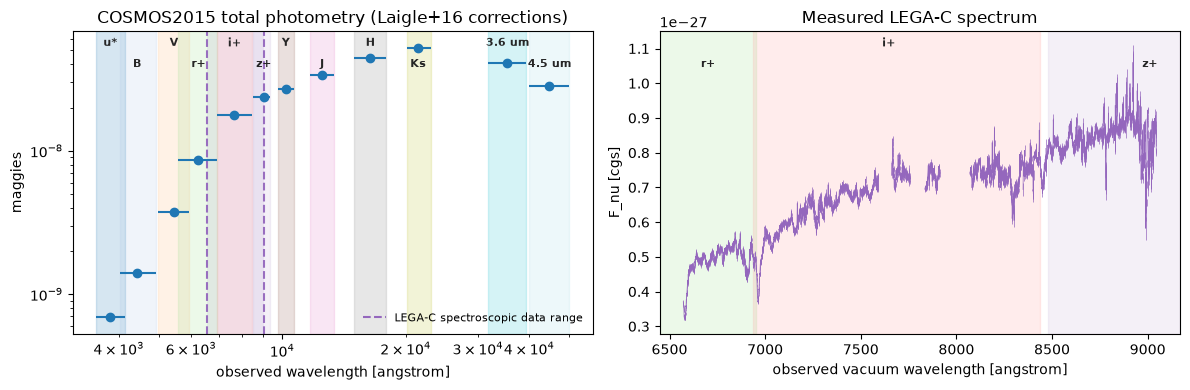

In [6]:
DR2_FLUX_UNIT = 1e-19 * u.erg / u.s / u.cm**2 / u.AA
SPECTRUM_CALIBRATION_INIT = 0.03
REST_EMISSION_LINES = EMISSION_LINES


def flam_to_fnu_cgs(values, wavelength):
    f_lambda = values * DR2_FLUX_UNIT
    return f_lambda.to_value(
        u.erg / u.s / u.cm**2 / u.Hz,
        equivalencies=u.spectral_density(wavelength * u.AA),
    )


if FIT_MODE == "full_spectrum":
    wave_vacuum = air_to_vac(wave_air * u.AA).to_value(u.AA)
    native_flux = flam_to_fnu_cgs(flux_dr2, wave_vacuum)
    native_uncertainty = flam_to_fnu_cgs(error_dr2, wave_vacuum)

    telluric_vacuum = air_to_vac(np.array([7590.0, 7660.0]) * u.AA).to_value(u.AA)
    native_valid = (
        good_pixel
        & np.isfinite(native_flux)
        & np.isfinite(native_uncertainty)
        & (native_uncertainty > 0)
    )
    spectrum_wave = wave_vacuum
    spectrum_flux = np.nan_to_num(native_flux, nan=0.0)
    spectrum_uncertainty = np.where(
        native_valid, native_uncertainty, 1.0
    )
    spectrum_obs = Spectrum(
        wavelength=spectrum_wave,
        flux=spectrum_flux,
        uncertainty=spectrum_uncertainty,
        mask=native_valid,
        resolution=instrument_fwhm_resolution,
        smoothtype="R",
        res_convention="fwhm",
        sigma_losvd=sigma_star,
        fit_sigma_smooth=FREE_SIGMA_FRAC > 0,
        **({"free_z": True} if FREE_ZRED_KMS > 0 else {}),
        name="spectrum",
    )
    spectrum_obs.mask_lines(
        REST_EMISSION_LINES,
        dv=1500.0,
        zred=z_catalog,
    )
    spectrum_obs.mask_wavelength_range(*telluric_vacuum)
    for rest_low, rest_high in MASK_REST_WINDOWS:
        spectrum_obs.mask_wavelength_range(
            rest_low * (1.0 + z_catalog), rest_high * (1.0 + z_catalog)
        )
    spectrum_mask = np.asarray(spectrum_obs.mask)

    assert good_pixel.sum() > 3000
    assert spectrum_obs.ndof > 0.7 * good_pixel.sum()

    spectrum_obs.display()
    print(f"joint photometric bands: {int(phot_fit_mask.sum())}")
    print("spectrum normalization: fitted by spectrum_scaling")
    print(f"native good pixels: {good_pixel.sum()}")
    print(f"fitted native pixels: {spectrum_obs.ndof}")
    print("library resolution: schema-2.1 automatic curve")

    spectrum_plot_flux = np.where(spectrum_mask, spectrum_flux, np.nan)
    spectrum_plot_uncertainty = np.where(
        spectrum_mask, spectrum_uncertainty, np.nan
    )

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].errorbar(
        filter_wave_eff,
        phot_flux,
        xerr=filter_wave_xerr,
        yerr=phot_uncertainty,
        fmt="o",
        color="tab:blue",
    )
    axes[0].set(
        xscale="log",
        yscale="log",
        xlabel="observed wavelength [angstrom]",
        ylabel="maggies",
    )
    axes[0].set_title(PHOTOMETRY_LABEL)
    axes[1].errorbar(
        spectrum_wave,
        spectrum_plot_flux,
        yerr=spectrum_plot_uncertainty,
        fmt="-",
        lw=0.5,
        color="tab:purple",
    )
    axes[1].set(
        xlabel="observed vacuum wavelength [angstrom]",
        ylabel="F_nu [cgs]",
    )
    axes[1].set_title("Measured LEGA-C spectrum")
    mark_filter_ranges(axes[0])
    mark_spectral_range(axes[0], show_label=True)
    axes[0].legend(frameon=False, fontsize=8)
    mark_filter_ranges(axes[1])
    plt.tight_layout()
    plt.show()
    spectroscopic_obs = spectrum_obs
else:
    INDEX_COLUMNS = [
        "LICK_CN1",
        "LICK_CN2",
        "LICK_CA4227",
        "LICK_G4300",
        "LICK_FE4383",
        "LICK_CA4455",
        "LICK_FE4531",
        "LICK_C4668",
        "LICK_HB",
        "LICK_HD_A",
        "LICK_HG_A",
        "LICK_HD_F",
        "LICK_HG_F",
        "LICK_D4000_N",
    ]
    EXPECTED_VALID_INDEX_COUNTS = {
        "M1_210210": 14,
        "M12_181945": 10,
        "M2_133501": 14,
        "M14_38648": 13,
    }
    index_values = galaxy[INDEX_COLUMNS].to_numpy(dtype=float)
    index_uncertainties = galaxy[
        [f"{column}_err" for column in INDEX_COLUMNS]
    ].to_numpy(dtype=float)
    index_mask = (
        np.isfinite(index_values)
        & np.isfinite(index_uncertainties)
        & (index_uncertainties > 0)
    )
    stellar_indices_obs = StellarIndices(
        definitions=LEGAC_DR2_STELLAR_INDEX_DEFINITIONS,
        values=index_values,
        uncertainty=index_uncertainties,
        mask=index_mask,
        resolution=instrument_fwhm_resolution,
        smoothtype="R",
        res_convention="fwhm",
        sigma_losvd=sigma_star,
        name="stellar_indices",
    )
    expected_count = EXPECTED_VALID_INDEX_COUNTS.get(TARGET_ID)
    if expected_count is not None:
        assert stellar_indices_obs.ndof == expected_count
    spectroscopic_obs = stellar_indices_obs

    stellar_indices_obs.display()
    print(f"valid published stellar indices: {stellar_indices_obs.ndof}")
    print(f"photometric bands fitted: {int(phot_fit_mask.sum())}")
    print("index covariance unavailable: using catalogue diagonal uncertainties")
    print("library resolution: schema-2.1 automatic curve")


## Stellar-population grid

- Load the published alpha-enhanced C3K high-resolution grid.
- Limit every SFH to the catalogue-redshift universe age.

In [7]:
grid_path = fetch_grid("amist_c3k_hr_krou_afe")
ssp = SSPDataAfe.load(grid_path)
ssp.display()

universe_age = float(age_gyr(z_catalog))
lookback_template = np.array([0.0, 0.03, 0.1, 0.3, 1.0, 3.0, 5.0, universe_age])

assert ssp.ssp_flux.shape[0] == 5
assert np.all(np.isfinite(ssp.ssp_resolution))
grid_wave = np.asarray(ssp.ssp_wave)
grid_resolving_power = np.median(grid_wave[:-1] / np.diff(grid_wave))
assert np.isclose(grid_resolving_power, 6000.0, rtol=0.01)
assert lookback_template[-1] <= 10 ** float(ssp.ssp_lg_age_gyr.max())
assert np.asarray(phot_obs.wave_eff).max() / (1 + z_catalog) < float(ssp.ssp_wave.max())

print(f"catalogue-redshift universe age: {universe_age:.3f} Gyr")
print(f"median grid pixel resolving power: R={grid_resolving_power:.0f}")
print(f"SFH nodes: {lookback_template}")

SSPDataAfe
------------------------------------------------------------------
provenance
  isochrones (isoc_type)   : MIST v2.5 (aMIST, alpha-variable)
  spectral library         : C3K v2.3 high-res (c3k_hr, vt=10 km/s)
  IMF (imf_type)           : 2
  FSPS version             : —
  schema version           : 2.1
  recorded wave_min/max    : 100.0 / 99595854.863
  build kwargs             : {'source_fits': 'ssp_final_mistv2.5_c3kv2.3vt10allfal_250722.fits', 'provider': 'M. J. Park (2025-07-22)', 'zsun_reference': 0.0185, 'feh_to_logZ': 'log10 Z = [Fe/H] + log10(Zsun)', 'imf_name': 'Kroupa'}
grids
  [alpha/Fe]               :    5 pts   [-0.2  0.   0.2  0.4  0.6]
  metallicity  log10 Z     :   13 pts   [-4.233, -1.233]  (absolute TOTAL Z, NOT Z/Zsun, NOT [Fe/H])
  age          log10(Gyr)  :  107 pts   [-4.000, +1.300]  = [0.0001, 20] Gyr
  wavelength   Angstrom    : 10992 pts   [100.0, 99595854.9]
  flux (n_afe,n_met,n_age,n_wave): (5, 13, 107, 10992)  [L_sun Hz^-1 M_sun^-1]  float64  5

catalogue-redshift universe age: 7.880 Gyr
median grid pixel resolving power: R=6000
SFH nodes: [0.         0.03       0.1        0.3        1.         3.
 5.         7.88040422]


## Joint model

- Share SFH, chemistry, dust, mass, and redshift.
- Apply fixed stellar broadening to spectroscopy.
- Sample calibration noise only for native spectra.
- Optional mock data from a stored truth vector, with a continuum tilt.
- Optional absorption-feature pixel selection: drop or down-weight continuum.


In [8]:
N_RATIOS = len(lookback_template) - 1
Z_BOUNDS = (
    float(ssp.ssp_lgmet.min()) + 1e-4,
    float(ssp.ssp_lgmet.max()) - 1e-4,
)
AFE_BOUNDS = (float(ssp.ssp_afe.min()), float(ssp.ssp_afe.max()))
FIXED_DUST_INDEX = -0.7
TAU_BOUNDS = (0.0, 2.0) if TAU_PRIOR == "uniform" else (0.0, 4.0)

csp_theta = {
    "lookback_time": jnp.asarray(lookback_template),
    "sfh": jnp.ones(len(lookback_template)),
    "Z": jnp.array([-1.85]),
    "afe": jnp.array([0.2]),
    "diffuse_tau_kc": jnp.array([0.2]),
    "diffuse_dust_index": jnp.array([FIXED_DUST_INDEX]),
}
joint_csp = CSPBasis_afe(
    ssp,
    theta=csp_theta,
    zh_const=True,
    sfh_interp="step",
    add_dust=False,
    add_diffuse_dust=True,
    add_dust_emission=False,
    add_igm=False,
    sigma_losvd_kms=0.0,
    track_zred_age=False,
    verbose=False,
)


def sfh_from_ratios(free_theta):
    return logsfr_ratios_to_sfh(
        free_theta["logsfr_ratios"],
        sfh_times_yr=np.asarray(joint_csp.sfh_times),
    )


joint_transforms = {"sfh": sfh_from_ratios}
if not FREE_DUST_INDEX:
    joint_transforms["diffuse_dust_index"] = lambda free_theta: jnp.array([FIXED_DUST_INDEX])
joint_priors = {
    "logsfr_ratios": (
        StudentT(mean=0.0, scale=0.3, df=2.0)
        if SFH_PRIOR == "student"
        else Uniform(low=-3.0, high=3.0)
    ),
    "Z": Uniform(low=Z_BOUNDS[0], high=Z_BOUNDS[1]),
    "afe": Uniform(low=AFE_BOUNDS[0], high=AFE_BOUNDS[1]),
    "logmass": Uniform(low=8.0, high=13.0),
    "diffuse_tau_kc": (
        Uniform(low=TAU_BOUNDS[0], high=TAU_BOUNDS[1])
        if TAU_PRIOR == "uniform"
        else ClippedNormal(mean=0.3, sigma=1.0, low=0.0, high=4.0)
    ),
}
if FREE_DUST_INDEX:
    joint_priors["diffuse_dust_index"] = Uniform(
        low=DUST_INDEX_BOUNDS[0], high=DUST_INDEX_BOUNDS[1]
    )
if FIT_MODE == "full_spectrum":
    joint_priors["log_f_calib"] = Uniform(
        low=np.log(0.01),
        high=np.log(FCALIB_MAX),
    )
    joint_priors["spectrum_scaling"] = ClippedNormal(
        mean=1.0, sigma=0.3, low=0.2, high=3.0
    )
ZRED_SIGMA = FREE_ZRED_KMS / C_KMS * (1.0 + z_catalog)
ZRED_BOUNDS = (z_catalog - 3.0 * ZRED_SIGMA, z_catalog + 3.0 * ZRED_SIGMA)
SIGMA_BOUNDS = (0.5 * sigma_star, 1.5 * sigma_star)
if FREE_ZRED_KMS > 0:
    joint_priors["zred"] = ClippedNormal(
        mean=z_catalog, sigma=ZRED_SIGMA, low=ZRED_BOUNDS[0], high=ZRED_BOUNDS[1]
    )
if FREE_SIGMA_FRAC > 0:
    joint_priors["sigma_smooth"] = ClippedNormal(
        mean=sigma_star, sigma=FREE_SIGMA_FRAC * sigma_star,
        low=SIGMA_BOUNDS[0], high=SIGMA_BOUNDS[1],
    )
joint_initial = {
    "logsfr_ratios": jnp.zeros(N_RATIOS),
    "logmass": jnp.array([11.0]),
}
if FREE_DUST_INDEX:
    joint_initial["diffuse_dust_index"] = jnp.array([FIXED_DUST_INDEX])
if FIT_MODE == "full_spectrum":
    joint_initial["log_f_calib"] = jnp.array(
        [np.log(SPECTRUM_CALIBRATION_INIT)]
    )
    joint_initial["spectrum_scaling"] = jnp.array([1.0])
if FREE_ZRED_KMS > 0:
    joint_initial["zred"] = jnp.array([z_catalog])
if FREE_SIGMA_FRAC > 0:
    joint_initial["sigma_smooth"] = jnp.array([sigma_star])
joint_bounds = {
    "logsfr_ratios": (-3.0, 3.0),
    "Z": Z_BOUNDS,
    "afe": AFE_BOUNDS,
    "logmass": (8.0, 13.0),
    "diffuse_tau_kc": TAU_BOUNDS,
}
if FREE_DUST_INDEX:
    joint_bounds["diffuse_dust_index"] = DUST_INDEX_BOUNDS
if FIT_MODE == "full_spectrum":
    joint_bounds["log_f_calib"] = (np.log(0.01), np.log(FCALIB_MAX))
    joint_bounds["spectrum_scaling"] = (0.2, 3.0)
if FREE_ZRED_KMS > 0:
    joint_bounds["zred"] = ZRED_BOUNDS
if FREE_SIGMA_FRAC > 0:
    joint_bounds["sigma_smooth"] = SIGMA_BOUNDS
joint_model = SedModel(
    joint_csp,
    observations=[phot_obs, spectroscopic_obs],
    priors=joint_priors,
    transforms=joint_transforms,
    free_param_init=joint_initial,
    zred=z_catalog,
)
assert sum(np.size(value) for value in joint_model.theta_init.values()) == (
    (13 if FIT_MODE == "full_spectrum" else 11)
    + int(FREE_ZRED_KMS > 0)
    + int(FREE_SIGMA_FRAC > 0)
    + int(FREE_DUST_INDEX)
)

MOCK_TRUTH = None
if MOCK_TRUTH_PATH:
    import json

    MOCK_TRUTH = {
        key: jnp.asarray(value, dtype=float)
        for key, value in json.loads(Path(MOCK_TRUTH_PATH).read_text()).items()
    }
    missing = set(joint_model.theta_init) - set(MOCK_TRUTH)
    assert not missing, f"mock truth lacks {sorted(missing)}"
    truth_theta = {key: MOCK_TRUTH[key] for key in joint_model.theta_init}
    truth_prediction = joint_model.predict(truth_theta)
    mock_rng = np.random.default_rng(MOCK_SEED)
    phot_flux = np.asarray(truth_prediction["photometry"]) + (
        phot_uncertainty * mock_rng.standard_normal(len(phot_uncertainty))
    )
    phot_obs.flux = jnp.asarray(phot_flux)
    fitted_wave = spectrum_wave[spectrum_mask]
    mock_tilt = 1.0 + MOCK_TILT * (
        2.0 * (spectrum_wave - fitted_wave.min()) / (fitted_wave.max() - fitted_wave.min())
        - 1.0
    )
    spectrum_uncertainty = np.where(
        native_valid, spectrum_uncertainty / MOCK_SNR_SCALE, 1.0
    )
    spectrum_flux = np.where(
        native_valid,
        np.asarray(truth_prediction["spectrum"]) * mock_tilt
        + spectrum_uncertainty * mock_rng.standard_normal(len(spectrum_wave)),
        0.0,
    )
    spectrum_obs.flux = jnp.asarray(spectrum_flux)
    spectrum_obs.uncertainty = jnp.asarray(spectrum_uncertainty)
    print(
        f"mock data: tilt {1 - MOCK_TILT:.3f}..{1 + MOCK_TILT:.3f} across the fitted range, "
        f"median pixel S/N {np.median(spectrum_flux[spectrum_mask] / spectrum_uncertainty[spectrum_mask]):.1f}"
    )

feature_mask = None
feature_downweight = float("nan")
if SPECTRUM_PIXELS != "all":
    if SPECTRUM_PIXELS == "features_downweight":
        in_feature = absorption_feature_mask(
            spectrum_wave, zred=z_catalog, window_kms=FEATURE_WINDOW_KMS
        )
        continuum = spectrum_mask & ~in_feature
        if FEATURE_DOWNWEIGHT == "balance":
            feature_downweight = float(np.sqrt(
                np.sum((spectrum_flux[continuum] / spectrum_uncertainty[continuum]) ** 2)
                / np.sum((phot_flux / phot_uncertainty) ** 2)
            ))
        else:
            feature_downweight = float(FEATURE_DOWNWEIGHT)
        feature_mask = spectrum_obs.select_absorption_features(
            zred=z_catalog,
            window_kms=FEATURE_WINDOW_KMS,
            mode="downweight",
            downweight=feature_downweight,
        )
        spectrum_uncertainty = np.asarray(spectrum_obs.uncertainty)
    else:
        feature_mask = spectrum_obs.select_absorption_features(
            zred=z_catalog, window_kms=FEATURE_WINDOW_KMS, mode="drop"
        )
    spectrum_mask = np.asarray(spectrum_obs.mask)
    print(f"pixel selection: {spectrum_obs.pixel_selection}")
    print(f"fitted native pixels after selection: {spectrum_obs.ndof}")

initial_photometry = np.asarray(
    joint_model.predict(joint_model.theta_init)["photometry"]
)
active_photometry = phot_fit_mask & (initial_photometry > 0) & (phot_flux > 0)
normalization_shift = np.median(
    np.log10(phot_flux[active_photometry] / initial_photometry[active_photometry])
)
joint_model.theta_init["logmass"] = (
    joint_model.theta_init["logmass"] + normalization_shift
)
initial_prediction = joint_model.predict(joint_model.theta_init)
joint_csp.check_param_ranges(joint_model.apply_transforms(joint_model.theta_init))

assert np.all(np.isfinite(np.asarray(initial_prediction["photometry"])))
assert np.all(
    np.isfinite(np.asarray(initial_prediction[spectroscopic_obs.name]))
)

if FREE_ZRED_KMS > 0:
    print(f"joint redshift free: prior {z_catalog:.4f} +/- {ZRED_SIGMA:.5f} ({FREE_ZRED_KMS:.0f} km/s)")
else:
    print(f"joint redshift fixed at {z_catalog:.4f}")
if FREE_SIGMA_FRAC > 0:
    print(f"spectrum sigma* free: prior {sigma_star:.1f} +/- {FREE_SIGMA_FRAC * sigma_star:.1f} km/s")
else:
    print(f"spectrum sigma* fixed at {sigma_star:.1f} km/s")
print(f"initial logmass: {float(joint_model.theta_init['logmass'][0]):.3f}")
if FIT_MODE == "full_spectrum":
    initial_spec_ratio = np.median(
        spectrum_flux[spectrum_mask]
        / np.asarray(initial_prediction["spectrum"])[spectrum_mask]
    )
    print(f"initial median spectrum/model ratio: {initial_spec_ratio:.3f}")
else:
    print(f"initial stellar-index predictions: {stellar_indices_obs.ndata}")


Using only diffuse dust attenuation.
Initializing DiffuseDust model...


Dust initialization complete.
Spectrum model: dust attenuation only (alpha-enhanced, no nebular)


joint redshift fixed at 0.6037
spectrum sigma* fixed at 223.8 km/s
initial logmass: 11.327
initial median spectrum/model ratio: 0.997


## Joint posterior

- Draw nested samples from every proper parameter prior.
- Use production convergence settings on Vast GPUs.
- Save checkpoints and the final posterior.
- Sum independent photometric and spectroscopic likelihoods.
- State the model parameters from the model object; store the text in both result files.

In [9]:
if RUN_PROFILE == "quick":
    joint_settings = {
        "num_live": 16,
        "num_inner_steps": 2,
        "num_delete": 8,
        "logZ_tol": 1e4,
    }
elif RUN_PROFILE == "cpu-trial":
    joint_settings = {
        "num_live": 150,
        "num_inner_steps": 24,
        "num_delete": 75,
        "logZ_tol": -2.0,
    }
else:
    joint_settings = {
        "num_live": 500,
        "num_inner_steps": 65,
        "num_delete": 100,
        "logZ_tol": -5.0,
    }

print(f"sampler settings: {joint_settings}")
joint_adapter = BlackJAXNestedSamplerAdapter(
    priors=joint_model.priors,
    num_live=joint_settings["num_live"],
    num_inner_steps=joint_settings["num_inner_steps"],
    num_delete=joint_settings["num_delete"],
    logZ_tol=joint_settings["logZ_tol"],
    checkpoint_interval_s=1200.0,
    checkpoint_dir=str(RESULT_DIR),
    verbose=True,
)
calibration_polynomial = None
if FIT_MODE == "full_spectrum" and CALIBRATION_ORDER > 0:
    # Coefficients are integrated out analytically at every call; the
    # constant term stays with the sampled spectrum_scaling.
    calibration_polynomial = PolynomialCalibration.from_spectrum(
        spectrum_obs,
        order=CALIBRATION_ORDER,
        fit_constant=False,
        prior_sigma=CALIBRATION_PRIOR_SIGMA,
        marginalize=True,
    )
spectroscopic_likelihood = (
    DiagonalGaussianLikelihood(
        noise_model=DiagonalNoiseModel(use_fractional=True),
        calibration=calibration_polynomial,
    )
    if FIT_MODE == "full_spectrum"
    else DiagonalGaussianLikelihood()
)
print(f"spectroscopic likelihood: {spectroscopic_likelihood!r}")
joint_likelihood = MultiObservationLikelihood(
    keys=(phot_obs.name, spectroscopic_obs.name),
    likelihoods=(DiagonalGaussianLikelihood(), spectroscopic_likelihood),
)
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from per_galaxy_diagnostics import model_parameter_block  # noqa: E402

model_parameter_block_text = model_parameter_block(
    joint_model, ssp, joint_likelihood, joint_settings, SEED
)
print(model_parameter_block_text)
joint_result = run_sampler(
    joint_model,
    joint_likelihood,
    joint_adapter,
    jax.random.PRNGKey(SEED),
)
result_path = RESULT_DIR / "ceridwen_result.h5"
write_result_h5(result_path, joint_model, joint_result)
with h5py.File(result_path, "r+") as result_file:
    result_file["model"].attrs["fit_mode"] = FIT_MODE
    result_file["model"].attrs["object_id"] = OBJECT_ID
    result_file["model"].attrs["manifest_index"] = MANIFEST_INDEX
    result_file["model"].attrs["random_seed"] = SEED
    result_file["model"].attrs["parameter_block"] = model_parameter_block_text
    result_file["model"].attrs["spectrum_pixels"] = SPECTRUM_PIXELS
    result_file["model"].attrs["feature_window_kms"] = FEATURE_WINDOW_KMS
    result_file["model"].attrs["feature_downweight"] = feature_downweight
    result_file["model"].attrs["mock_seed"] = MOCK_SEED
    result_file["model"].attrs["mock_tilt"] = MOCK_TILT
    result_file["model"].attrs["mock_snr_scale"] = MOCK_SNR_SCALE
    result_file["model"].attrs["photometry_source"] = PHOTOMETRY_SOURCE
    result_file["model"].attrs["calibration_order"] = CALIBRATION_ORDER
    result_file["model"].attrs["calibration_prior_sigma"] = CALIBRATION_PRIOR_SIGMA
    result_file["model"].attrs["calibration_marginalized"] = calibration_polynomial is not None
    result_file["model"].attrs["free_zred_kms"] = FREE_ZRED_KMS
    result_file["model"].attrs["free_sigma_frac"] = FREE_SIGMA_FRAC
    result_file["model"].attrs["fcalib_max"] = FCALIB_MAX
    result_file["model"].attrs["emission_lines"] = ",".join(str(line) for line in EMISSION_LINES)
    result_file["model"].attrs["mask_rest_windows"] = ",".join(
        f"{low}:{high}" for low, high in MASK_REST_WINDOWS
    )
    result_file["model"].attrs["phot_drop"] = ",".join(PHOT_DROP)
    result_file["model"].attrs["free_dust_index"] = FREE_DUST_INDEX
    result_file["model"].attrs["sfh_prior"] = SFH_PRIOR
    result_file["model"].attrs["tau_prior"] = TAU_PRIOR
    result_file["model"].attrs["dust_index_bounds"] = ",".join(str(edge) for edge in DUST_INDEX_BOUNDS)
    if MOCK_TRUTH is not None:
        truth_group = result_file.create_group("mock_truth")
        for key, value in MOCK_TRUTH.items():
            truth_group.create_dataset(key, data=np.asarray(value))
    result_file["model"].attrs["has_4000a_coverage"] = has_4000a_coverage
    result_file["model"].attrs["sfh_basis_fastpath"] = bool(
        joint_csp.sfh_basis_fastpath
    )
    for setting, value in joint_settings.items():
        result_file["samples"].attrs[setting] = value
saved_result = load_result_h5(result_path)
assert saved_result.param_names == joint_result.param_names
assert saved_result.log_likelihoods.shape == joint_result.log_likelihoods.shape
print(f"saved result: {result_path}")
print(joint_result.summary())

sampler settings: {'num_live': 500, 'num_inner_steps': 65, 'num_delete': 100, 'logZ_tol': -5.0}
spectroscopic likelihood: DiagonalGaussianLikelihood(noise_model=DiagonalNoiseModel(use_jitter=False, use_fractional=True, use_data_fractional=False), calibration=PolynomialCalibration(order=3, fit_constant=False, prior_sigma=(0.1, 0.1, 0.1), marginalize=True, n_pix=6166))


MODEL PARAMETERS (generated from the SedModel object)
Stellar population grid
  library: C3K v2.3 high-res (c3k_hr, vt=10 km/s); isochrones: MIST v2.5 (aMIST, alpha-variable); IMF: imf_type=2 (Kroupa (2001)); schema 2.1
  grid axes: [alpha/Fe] [-0.2, 0, 0.2, 0.4, 0.6]; log10 Z 13 nodes [-4.233, -1.233] (absolute Z); log10(age/Gyr) 107 nodes; wavelength 10992 pts [100, 99595855] A
Star-formation history
  form: piecewise-constant SFR ('step' interpolation) on 7 lookback bins; metallicity history: constant Z
  bin edges (lookback, Gyr): [0, 0.03, 0.1, 0.3, 1, 3, 5, 7.88]  (last edge = universe age at z)
  free parameters: logsfr_ratios[7] = log10(SFR_i / SFR_i+1), transform 'sfh_from_ratios' -> unit-mass SFH (integral 1 Msun); logmass scales the total formed mass
Free parameters and priors
  Z: shape (1,); prior Uniform(-4.233, -1.233); init [-1.85]
  afe: shape (1,); prior Uniform(-0.2, 0.6); init [0.2]
  diffuse_dust_index: shape (1,); prior Uniform(-1, 0.4); init [-0.7]
  diffuse_tau_

BlackJAX NSS  |  n_dims=14  num_live=500  num_inner_steps=65  num_delete=100


  [timing] Calling init_fn (JIT compile + eval) ...


  [timing] init_fn done    (4.5 s)  logZ=-inf  logZ_live=228172.9400


...

NS  logZ=233019.59  ΔlogZ=-4.90: : 21800 dead [09:12, 39.13 dead/s]

NS  logZ=233019.59  ΔlogZ=-5.06: : 21800 dead [09:12, 39.13 dead/s]

NS  logZ=233019.59  ΔlogZ=-5.06: : 21800 dead [09:12, 39.46 dead/s]

  Converged  logZ = 233019.594  (552.5 s,  8,784,897 likelihood calls)


saved result: /workspace/cosmic-chronometers-jwst/results/fit-accuracy-knobs/new_default_rep1/172669-M5_172669/ceridwen_result.h5
blackjax.nss  |  n_samples=22300  ln Z = 233019.644 ± 0.353  |  n_like = 8784897  |  wall = 552.5 s


## Sampling diagnostics

- Report evidence and posterior-weight effective sample size.
- Measure information gain using normalized nested-sampling weights.

In [10]:
def diagnostic_table(result, model, bounds):
    weights = softmax(np.asarray(result.log_weights))
    rows = []
    for name, parameter_template in model.theta_init.items():
        size = int(np.size(parameter_template))
        samples = np.asarray(result.samples[name]).reshape(len(weights), size)
        for component in range(size):
            low, high = bounds[name]
            counts, _ = np.histogram(
                samples[:, component],
                bins=30,
                range=(low, high),
                weights=weights,
            )
            probabilities = (counts + 1e-12) / np.sum(counts + 1e-12)
            uniform = np.full(30, 1 / 30)
            rows.append(
                {
                    "parameter": name if size == 1 else f"{name}[{component}]",
                    "KL posterior||prior": entropy(probabilities, uniform),
                }
            )
    return pd.DataFrame(rows), weights


def equal_weight_posterior(result, weights, count, seed):
    rng = np.random.default_rng(seed)
    indices = rng.choice(len(weights), size=count, replace=True, p=weights)
    return {name: np.asarray(values)[indices] for name, values in result.samples.items()}


joint_diagnostics, joint_weights = diagnostic_table(
    joint_result,
    joint_model,
    joint_bounds,
)
display(joint_diagnostics)

joint_weight_ess = 1.0 / np.sum(joint_weights**2)
joint_diagnostics_passed = (
    np.isfinite(joint_result.log_evidence)
    and np.isfinite(joint_result.log_evidence_err)
    and joint_weight_ess >= 200
)
joint_status = (
    "diagnostics passed"
    if RUN_PROFILE == "gpu-full" and joint_diagnostics_passed
    else f"{RUN_PROFILE}: exploratory"
)
joint_posterior = equal_weight_posterior(
    joint_result,
    joint_weights,
    count=2000,
    seed=SEED + 1,
)
print("joint fit:", joint_status)
print(f"ln Z: {joint_result.log_evidence:.3f} +/- {joint_result.log_evidence_err:.3f}")
print(f"posterior-weight ESS: {joint_weight_ess:.1f}")
print(f"likelihood calls: {joint_result.n_likelihood_calls}")

,parameter,KL posterior||prior
0,Z,3.198462
1,afe,2.412750
2,diffuse_ta...,2.707160
3,diffuse_du...,2.693138
4,logsfr_rat...,1.523649
5,logsfr_rat...,1.639684
6,logsfr_rat...,1.727542
7,logsfr_rat...,1.472918
8,logsfr_rat...,1.646028
9,logsfr_rat...,1.428160


joint fit: diagnostics passed
ln Z: 233019.644 +/- 0.353
posterior-weight ESS: 4262.3
likelihood calls: 8784897


## Posterior predictive checks

- Plot photometry against the shared posterior model.
- Plot native residuals or index residuals by unit.
- Include calibration noise only for native spectra.


findfont: Failed to find font weight semibold, now using 700.


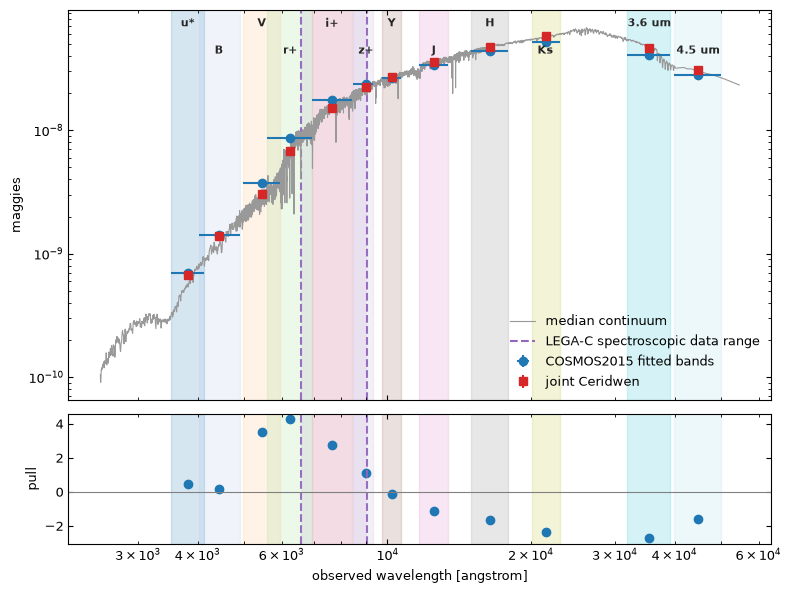

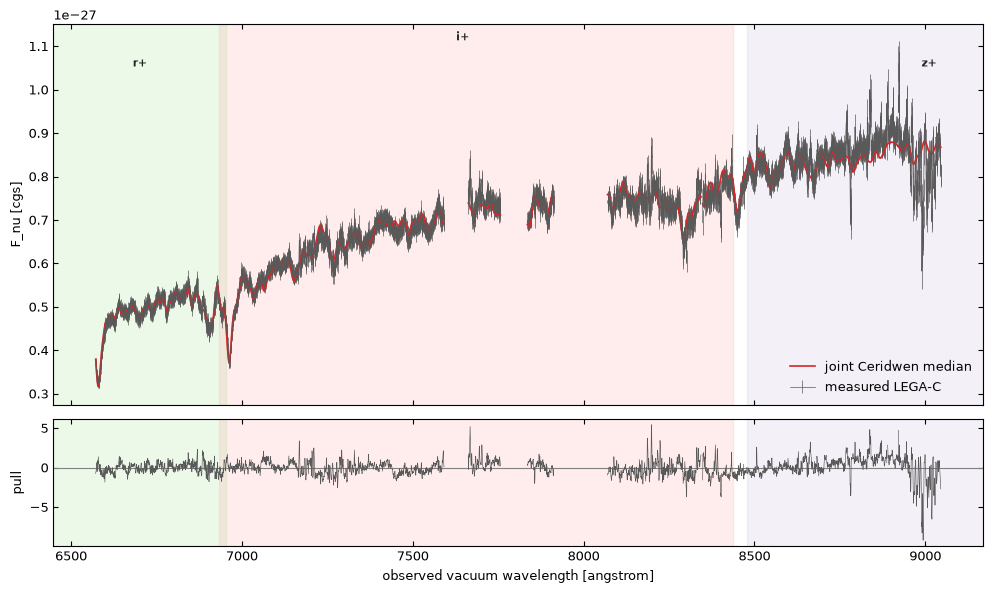

photometry chi2/datum: 4.92
spectrum chi2/bin: 1.15
joint chi2/datum: 1.16
sampled calibration floor: 2.67%


In [11]:
def posterior_batch(samples, model, count):
    total = len(next(iter(samples.values())))
    indices = np.linspace(0, total - 1, min(count, total), dtype=int)
    batch = {}
    for name, parameter_template in model.theta_init.items():
        values = np.asarray(samples[name])[indices]
        if np.shape(parameter_template) == (1,) and values.ndim == 1:
            values = values[:, None]
        batch[name] = jnp.asarray(values)
    return batch


if FIT_MODE == "full_spectrum":
    joint_predictions = joint_model.predict_vmap(
        posterior_batch(joint_posterior, joint_model, 200)
    )
    phot_predictions = np.asarray(joint_predictions["photometry"])
    spectrum_predictions = np.asarray(joint_predictions["spectrum"])
    calibration_coefficients = None
    calibration_vectors = None
    predictive_batch = posterior_batch(joint_posterior, joint_model, 200)
    if calibration_polynomial is not None:
        # Per draw: the noise model's sigma at the uncalibrated model, then one
        # coefficient draw from N(a_hat, N^-1); P(lambda) multiplies the prediction.
        predictive_sigma = np.hypot(
            spectrum_uncertainty[None, :],
            np.exp(np.asarray(predictive_batch["log_f_calib"]).reshape(-1, 1))
            * np.abs(spectrum_predictions),
        )
        calibration_coefficients, calibration_vectors = (
            np.asarray(value)
            for value in calibration_polynomial.posterior_draws(
                spectrum_flux,
                spectrum_predictions,
                predictive_sigma,
                spectrum_mask,
                jax.random.PRNGKey(SEED + 2),
            )
        )
        spectrum_predictions = spectrum_predictions * calibration_vectors
    phot_q16, phot_q50, phot_q84 = np.percentile(
        phot_predictions,
        [16, 50, 84],
        axis=0,
    )
    spec_q16, spec_q50, spec_q84 = np.percentile(
        spectrum_predictions,
        [16, 50, 84],
        axis=0,
    )

    median_theta = {
        name: jnp.atleast_1d(np.median(np.asarray(values), axis=0))
        for name, values in joint_posterior.items()
    }
    physical_theta = joint_model.apply_transforms(median_theta)
    continuum = (
        np.asarray(joint_csp.get_spectrum(physical_theta))
        * 10 ** float(median_theta["logmass"][0])
        * float(flux_factor_maggies(z_catalog))
        / CGS_FNU_PER_MAGGIE
    )
    continuum_wave = np.asarray(joint_csp.wave) * (1 + z_catalog)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8, 6),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )
    wave_eff = filter_wave_eff
    continuum_mask = (continuum_wave > 2500) & (continuum_wave < 55000)
    axes[0].plot(
        continuum_wave[continuum_mask],
        continuum[continuum_mask],
        color="0.6",
        lw=0.8,
        label="median continuum",
    )
    axes[0].errorbar(
        wave_eff[phot_fit_mask],
        phot_flux[phot_fit_mask],
        xerr=filter_wave_xerr[:, phot_fit_mask],
        yerr=phot_uncertainty[phot_fit_mask],
        fmt="o",
        color="tab:blue",
        label="COSMOS2015 fitted bands",
    )
    axes[0].errorbar(
        wave_eff,
        phot_q50,
        yerr=[phot_q50 - phot_q16, phot_q84 - phot_q50],
        fmt="s",
        color="tab:red",
        label="joint Ceridwen",
    )
    axes[0].set(xscale="log", yscale="log", ylabel="maggies")
    mark_filter_ranges(axes[0])
    mark_spectral_range(axes[0], show_label=True)
    axes[0].legend(frameon=False)
    axes[1].axhline(0, color="0.5", lw=0.8)
    axes[1].scatter(
        wave_eff[phot_fit_mask],
        (phot_flux[phot_fit_mask] - phot_q50[phot_fit_mask])
        / phot_uncertainty[phot_fit_mask],
        color="tab:blue",
    )
    mark_filter_ranges(axes[1], show_labels=False)
    mark_spectral_range(axes[1])
    axes[1].set(
        xscale="log",
        xlabel="observed wavelength [angstrom]",
        ylabel="pull",
    )
    plt.tight_layout()
    plt.show()

    calibration_fraction = float(
        np.exp(np.median(np.asarray(joint_posterior["log_f_calib"])))
    )
    effective_spec_uncertainty = np.hypot(
        spectrum_uncertainty,
        calibration_fraction * np.abs(spec_q50),
    )
    spectrum_plot_flux = np.where(spectrum_mask, spectrum_flux, np.nan)
    spectrum_plot_uncertainty = np.where(
        spectrum_mask, effective_spec_uncertainty, np.nan
    )
    spectrum_plot_q16 = np.where(spectrum_mask, spec_q16, np.nan)
    spectrum_plot_q50 = np.where(spectrum_mask, spec_q50, np.nan)
    spectrum_plot_q84 = np.where(spectrum_mask, spec_q84, np.nan)
    spectrum_plot_pull = np.where(
        spectrum_mask,
        (spectrum_flux - spec_q50) / effective_spec_uncertainty,
        np.nan,
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )
    axes[0].errorbar(
        spectrum_wave,
        spectrum_plot_flux,
        yerr=spectrum_plot_uncertainty,
        fmt="-",
        lw=0.5,
        color="0.35",
        label="measured LEGA-C",
    )
    axes[0].plot(
        spectrum_wave,
        spectrum_plot_q50,
        color="tab:red",
        lw=1.2,
        label="joint Ceridwen median",
    )
    axes[0].fill_between(
        spectrum_wave,
        spectrum_plot_q16,
        spectrum_plot_q84,
        color="tab:red",
        alpha=0.25,
    )
    axes[0].set(ylabel="F_nu [cgs]")
    axes[0].legend(frameon=False)
    axes[1].axhline(0, color="0.5", lw=0.8)
    axes[1].plot(
        spectrum_wave,
        spectrum_plot_pull,
        lw=0.45,
        color="0.35",
    )
    axes[1].set(xlabel="observed vacuum wavelength [angstrom]", ylabel="pull")
    mark_filter_ranges(axes[0])
    mark_filter_ranges(axes[1], show_labels=False)
    plt.tight_layout()
    plt.show()

    phot_chi2 = np.sum(
        (
            (phot_flux[phot_fit_mask] - phot_q50[phot_fit_mask])
            / phot_uncertainty[phot_fit_mask]
        )
        ** 2
    )
    spectrum_chi2 = np.sum(
        (
            (spectrum_flux[spectrum_mask] - spec_q50[spectrum_mask])
            / effective_spec_uncertainty[spectrum_mask]
        )
        ** 2
    )
    joint_chi2 = phot_chi2 + spectrum_chi2
    joint_points = phot_obs.ndof + spectrum_obs.ndof

    print(f"photometry chi2/datum: {phot_chi2 / phot_obs.ndof:.2f}")
    print(f"spectrum chi2/bin: {spectrum_chi2 / spectrum_obs.ndof:.2f}")
    print(f"joint chi2/datum: {joint_chi2 / joint_points:.2f}")
    print(f"sampled calibration floor: {100 * calibration_fraction:.2f}%")
    spectroscopic_chi2 = spectrum_chi2
else:
    joint_predictions = joint_model.predict_vmap(
        posterior_batch(joint_posterior, joint_model, 200)
    )
    phot_predictions = np.asarray(joint_predictions["photometry"])
    index_predictions = np.asarray(joint_predictions["stellar_indices"])
    phot_q16, phot_q50, phot_q84 = np.percentile(
        phot_predictions,
        [16, 50, 84],
        axis=0,
    )
    index_q16, index_q50, index_q84 = np.percentile(
        index_predictions,
        [16, 50, 84],
        axis=0,
    )
    index_values = np.asarray(stellar_indices_obs.flux)
    index_uncertainties = np.asarray(stellar_indices_obs.uncertainty)
    index_mask = np.asarray(stellar_indices_obs.mask)
    index_pull = np.where(
        index_mask,
        (index_values - index_q50) / index_uncertainties,
        np.nan,
    )

    median_theta = {
        name: jnp.atleast_1d(np.median(np.asarray(values), axis=0))
        for name, values in joint_posterior.items()
    }
    physical_theta = joint_model.apply_transforms(median_theta)
    continuum = (
        np.asarray(joint_csp.get_spectrum(physical_theta))
        * 10 ** float(median_theta["logmass"][0])
        * float(flux_factor_maggies(z_catalog))
        / CGS_FNU_PER_MAGGIE
    )
    continuum_wave = np.asarray(joint_csp.wave) * (1 + z_catalog)

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(8, 6),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )
    wave_eff = filter_wave_eff
    continuum_mask = (continuum_wave > 2500) & (continuum_wave < 55000)
    axes[0].plot(
        continuum_wave[continuum_mask],
        continuum[continuum_mask],
        color="0.6",
        lw=0.8,
        label="median continuum",
    )
    axes[0].errorbar(
        wave_eff[phot_fit_mask],
        phot_flux[phot_fit_mask],
        xerr=filter_wave_xerr[:, phot_fit_mask],
        yerr=phot_uncertainty[phot_fit_mask],
        fmt="o",
        color="tab:blue",
        label="COSMOS2015 fitted bands",
    )
    axes[0].errorbar(
        wave_eff,
        phot_q50,
        yerr=[phot_q50 - phot_q16, phot_q84 - phot_q50],
        fmt="s",
        color="tab:red",
        label="joint Ceridwen",
    )
    axes[0].set(xscale="log", yscale="log", ylabel="maggies")
    mark_filter_ranges(axes[0])
    axes[0].legend(frameon=False)
    axes[1].axhline(0, color="0.5", lw=0.8)
    axes[1].scatter(
        wave_eff[phot_fit_mask],
        (phot_flux[phot_fit_mask] - phot_q50[phot_fit_mask])
        / phot_uncertainty[phot_fit_mask],
        color="tab:blue",
    )
    mark_filter_ranges(axes[1], show_labels=False)
    axes[1].set(
        xscale="log",
        xlabel="observed wavelength [angstrom]",
        ylabel="pull",
    )
    plt.tight_layout()
    plt.show()

    index_groups = [
        ("equivalent_width", r"equivalent width [$\mathrm{\AA}$]"),
        ("magnitude", "magnitude [mag]"),
        ("flux_ratio", r"$D_n4000$"),
    ]
    fig, axes = plt.subplots(
        2,
        len(index_groups),
        figsize=(14, 6),
        gridspec_kw={"height_ratios": [3, 1]},
    )
    for column, (kind, ylabel) in enumerate(index_groups):
        group = np.array(stellar_indices_obs.index_kinds) == kind
        group &= index_mask
        positions = np.arange(group.sum())
        labels = np.array(stellar_indices_obs.index_names)[group]
        axes[0, column].errorbar(
            positions - 0.08,
            index_values[group],
            yerr=index_uncertainties[group],
            fmt="o",
            color="tab:blue",
            label="LEGA-C catalogue",
        )
        axes[0, column].errorbar(
            positions + 0.08,
            index_q50[group],
            yerr=[
                index_q50[group] - index_q16[group],
                index_q84[group] - index_q50[group],
            ],
            fmt="s",
            color="tab:red",
            label="Ceridwen posterior",
        )
        axes[0, column].set_ylabel(ylabel)
        axes[0, column].set_xticks(positions, labels, rotation=45, ha="right")
        axes[1, column].axhspan(-1, 1, color="0.85", alpha=0.55, linewidth=0)
        axes[1, column].axhline(0, color="k", lw=0.8)
        axes[1, column].scatter(positions, index_pull[group], color="0.35")
        axes[1, column].set_xticks(positions, labels, rotation=45, ha="right")
        axes[1, column].set_ylabel("pull")
    axes[0, 0].legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

    phot_chi2 = np.sum(
        (
            (phot_flux[phot_fit_mask] - phot_q50[phot_fit_mask])
            / phot_uncertainty[phot_fit_mask]
        )
        ** 2
    )
    spectroscopic_chi2 = np.sum(index_pull[index_mask] ** 2)
    joint_chi2 = phot_chi2 + spectroscopic_chi2
    joint_points = phot_obs.ndof + stellar_indices_obs.ndof

    print(f"photometry chi2/datum: {phot_chi2 / phot_obs.ndof:.2f}")
    print(
        "stellar indices chi2/datum: "
        f"{spectroscopic_chi2 / stellar_indices_obs.ndof:.2f}"
    )
    print(f"joint chi2/datum: {joint_chi2 / joint_points:.2f}")


## Spectroscopic comparison

- Show every native pixel used by full mode.
- Tabulate observed and predicted stellar indices otherwise.


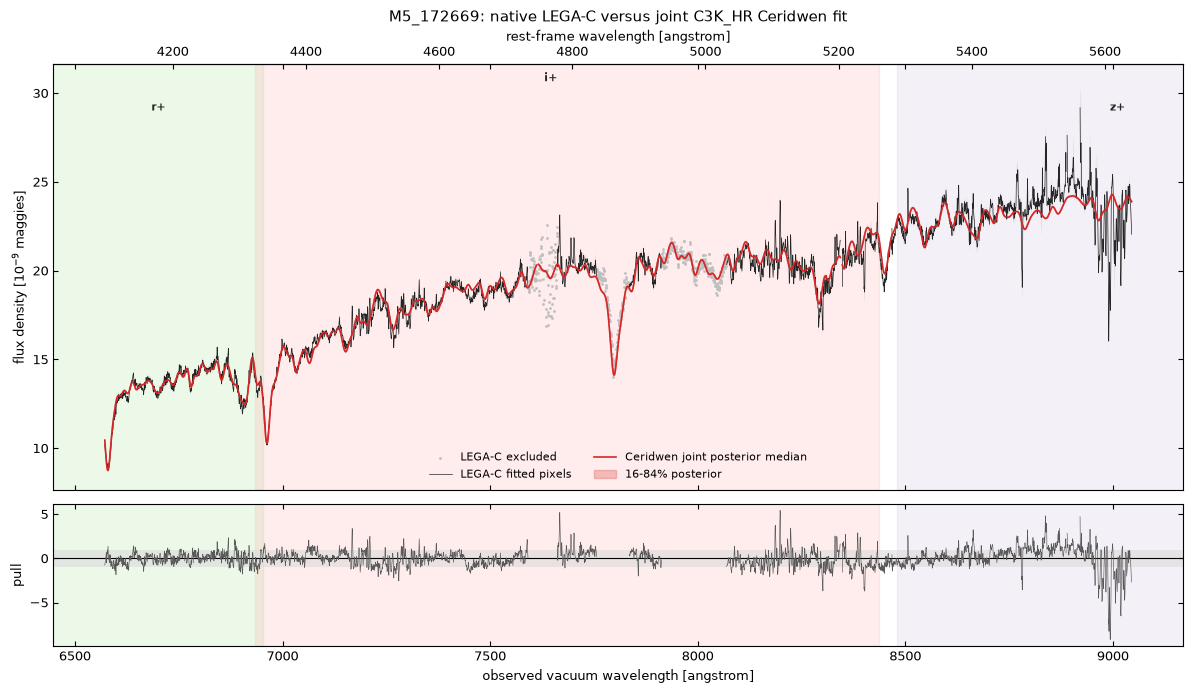

native valid pixels shown: 4096
native residual pixels after masks: 3602
native spectrum is the fitted high-resolution likelihood


In [12]:
if FIT_MODE == "full_spectrum":
    native_plot_flux = spectrum_flux
    native_plot_uncertainty = spectrum_uncertainty
    native_fit_mask = spectrum_mask
    native_q16, native_q50, native_q84 = spec_q16, spec_q50, spec_q84
    native_effective_uncertainty = np.hypot(
        native_plot_uncertainty,
        calibration_fraction * np.abs(native_q50),
    )
    native_excluded_mask = native_valid & ~native_fit_mask
    native_plot_scale = 1e9 / CGS_FNU_PER_MAGGIE
    native_fitted_flux = np.where(native_fit_mask, native_plot_flux, np.nan)
    native_fitted_uncertainty = np.where(
        native_fit_mask, native_plot_uncertainty, np.nan
    )
    native_plot_q16 = np.where(native_valid, native_q16, np.nan)
    native_plot_q50 = np.where(native_valid, native_q50, np.nan)
    native_plot_q84 = np.where(native_valid, native_q84, np.nan)
    native_plot_pull = np.where(
        native_fit_mask,
        (native_plot_flux - native_q50) / native_effective_uncertainty,
        np.nan,
    )

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(12, 7),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )
    axes[0].scatter(
        wave_vacuum[native_excluded_mask],
        native_plot_flux[native_excluded_mask] * native_plot_scale,
        s=4,
        color="0.75",
        linewidths=0,
        label="LEGA-C excluded",
        rasterized=True,
    )
    axes[0].fill_between(
        wave_vacuum,
        (native_fitted_flux - native_fitted_uncertainty)
        * native_plot_scale,
        (native_fitted_flux + native_fitted_uncertainty)
        * native_plot_scale,
        color="0.5",
        alpha=0.18,
        linewidth=0,
    )
    axes[0].plot(
        wave_vacuum,
        native_fitted_flux * native_plot_scale,
        color="0.15",
        lw=0.5,
        label="LEGA-C fitted pixels",
        rasterized=True,
    )
    axes[0].plot(
        wave_vacuum,
        native_plot_q50 * native_plot_scale,
        color="tab:red",
        lw=1.2,
        label="Ceridwen joint posterior median",
    )
    axes[0].fill_between(
        wave_vacuum,
        native_plot_q16 * native_plot_scale,
        native_plot_q84 * native_plot_scale,
        color="tab:red",
        alpha=0.25,
        label="16-84% posterior",
    )
    axes[0].set(ylabel=r"flux density [$10^{-9}$ maggies]")
    axes[0].set_title(
        f"{TARGET_ID}: native LEGA-C versus joint C3K_HR Ceridwen fit"
    )
    axes[0].legend(frameon=False, ncol=2, fontsize=8)
    axes[1].axhspan(-1, 1, color="0.85", alpha=0.55, linewidth=0)
    axes[1].axhline(0, color="k", lw=0.8)
    axes[1].plot(
        wave_vacuum,
        native_plot_pull,
        color="0.35",
        lw=0.45,
        rasterized=True,
    )
    axes[1].set(
        xlabel="observed vacuum wavelength [angstrom]",
        ylabel="pull",
    )
    mark_filter_ranges(axes[0])
    mark_filter_ranges(axes[1], show_labels=False)
    secondary_axis = axes[0].secondary_xaxis(
        "top",
        functions=(
            lambda observed: observed / (1 + z_catalog),
            lambda rest: rest * (1 + z_catalog),
        ),
    )
    secondary_axis.set_xlabel("rest-frame wavelength [angstrom]")
    plt.tight_layout()
    plt.show()

    print(f"native valid pixels shown: {native_valid.sum()}")
    print(f"native residual pixels after masks: {native_fit_mask.sum()}")
    print("native spectrum is the fitted high-resolution likelihood")
else:
    index_summary = pd.DataFrame(
        {
            "index": stellar_indices_obs.index_names,
            "unit": stellar_indices_obs.index_units,
            "fitted": np.asarray(stellar_indices_obs.mask),
            "observed": np.asarray(stellar_indices_obs.flux),
            "uncertainty": np.asarray(stellar_indices_obs.uncertainty),
            "posterior_q16": index_q16,
            "posterior_median": index_q50,
            "posterior_q84": index_q84,
            "pull": index_pull,
        }
    )
    display(index_summary)


## Calibration polynomial

- Posterior of $P(\lambda)$: median and 16-84 band over draws.
- Full calibration vector is $s_{\mathrm{spectrum}}\,P(\lambda)$.
- Dotted where pixels are masked.


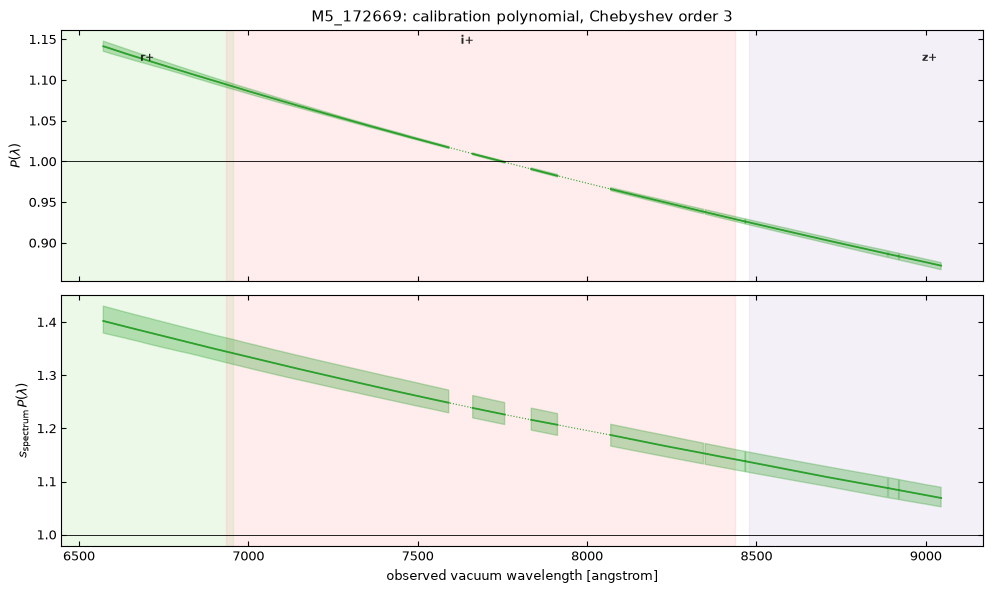

,coefficient,q16,q50,q84
0,a_1,-0.139447,-0.134042,-0.129701
1,a_2,0.005195,0.006514,0.007886
2,a_3,-0.001540,-0.000589,0.000192


P(lambda) median over fitted pixels: 0.8720 - 1.1413
end-to-end tilt P(red) / P(blue) - 1: -0.2360


In [13]:
if calibration_polynomial is not None:
    poly_q16, poly_q50, poly_q84 = np.percentile(
        calibration_vectors, [16, 50, 84], axis=0
    )
    scaling_draws = np.asarray(predictive_batch["spectrum_scaling"]).reshape(-1)
    full_q16, full_q50, full_q84 = np.percentile(
        calibration_vectors * scaling_draws[:, None], [16, 50, 84], axis=0
    )
    fitted_range = (
        (spectrum_wave >= spectrum_wave[spectrum_mask].min())
        & (spectrum_wave <= spectrum_wave[spectrum_mask].max())
    )
    fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
    bands = [
        (poly_q16, poly_q50, poly_q84, r"$P(\lambda)$"),
        (full_q16, full_q50, full_q84, r"$s_{\mathrm{spectrum}}\,P(\lambda)$"),
    ]
    for ax, (q16, q50, q84, label) in zip(axes, bands):
        ax.fill_between(
            spectrum_wave,
            np.where(spectrum_mask, q16, np.nan),
            np.where(spectrum_mask, q84, np.nan),
            color="tab:green",
            alpha=0.3,
        )
        ax.plot(
            spectrum_wave,
            np.where(fitted_range, q50, np.nan),
            color="tab:green",
            lw=0.8,
            ls=":",
        )
        ax.plot(
            spectrum_wave,
            np.where(spectrum_mask, q50, np.nan),
            color="tab:green",
            lw=1.3,
        )
        ax.axhline(1.0, color="k", lw=0.6)
        ax.set_ylabel(label)
    axes[1].set_xlabel("observed vacuum wavelength [angstrom]")
    axes[0].set_title(f"{TARGET_ID}: calibration polynomial, Chebyshev order {CALIBRATION_ORDER}")
    mark_filter_ranges(axes[0])
    mark_filter_ranges(axes[1], show_labels=False)
    plt.tight_layout()
    plt.show()

    coefficient_table = pd.DataFrame(
        {
            "coefficient": [f"a_{n}" for n in range(1, CALIBRATION_ORDER + 1)],
            "q16": np.percentile(calibration_coefficients, 16, axis=0),
            "q50": np.percentile(calibration_coefficients, 50, axis=0),
            "q84": np.percentile(calibration_coefficients, 84, axis=0),
        }
    )
    display(coefficient_table)
    fitted_q50 = poly_q50[spectrum_mask]
    print(
        f"P(lambda) median over fitted pixels: {fitted_q50.min():.4f} - {fitted_q50.max():.4f}"
    )
    print(f"end-to-end tilt P(red) / P(blue) - 1: {fitted_q50[-1] / fitted_q50[0] - 1:+.4f}")


## Population summary

- Align direct and derived quantities to deterministic posterior rows.
- Compare physical parameters, age, and formed-mass fractions.

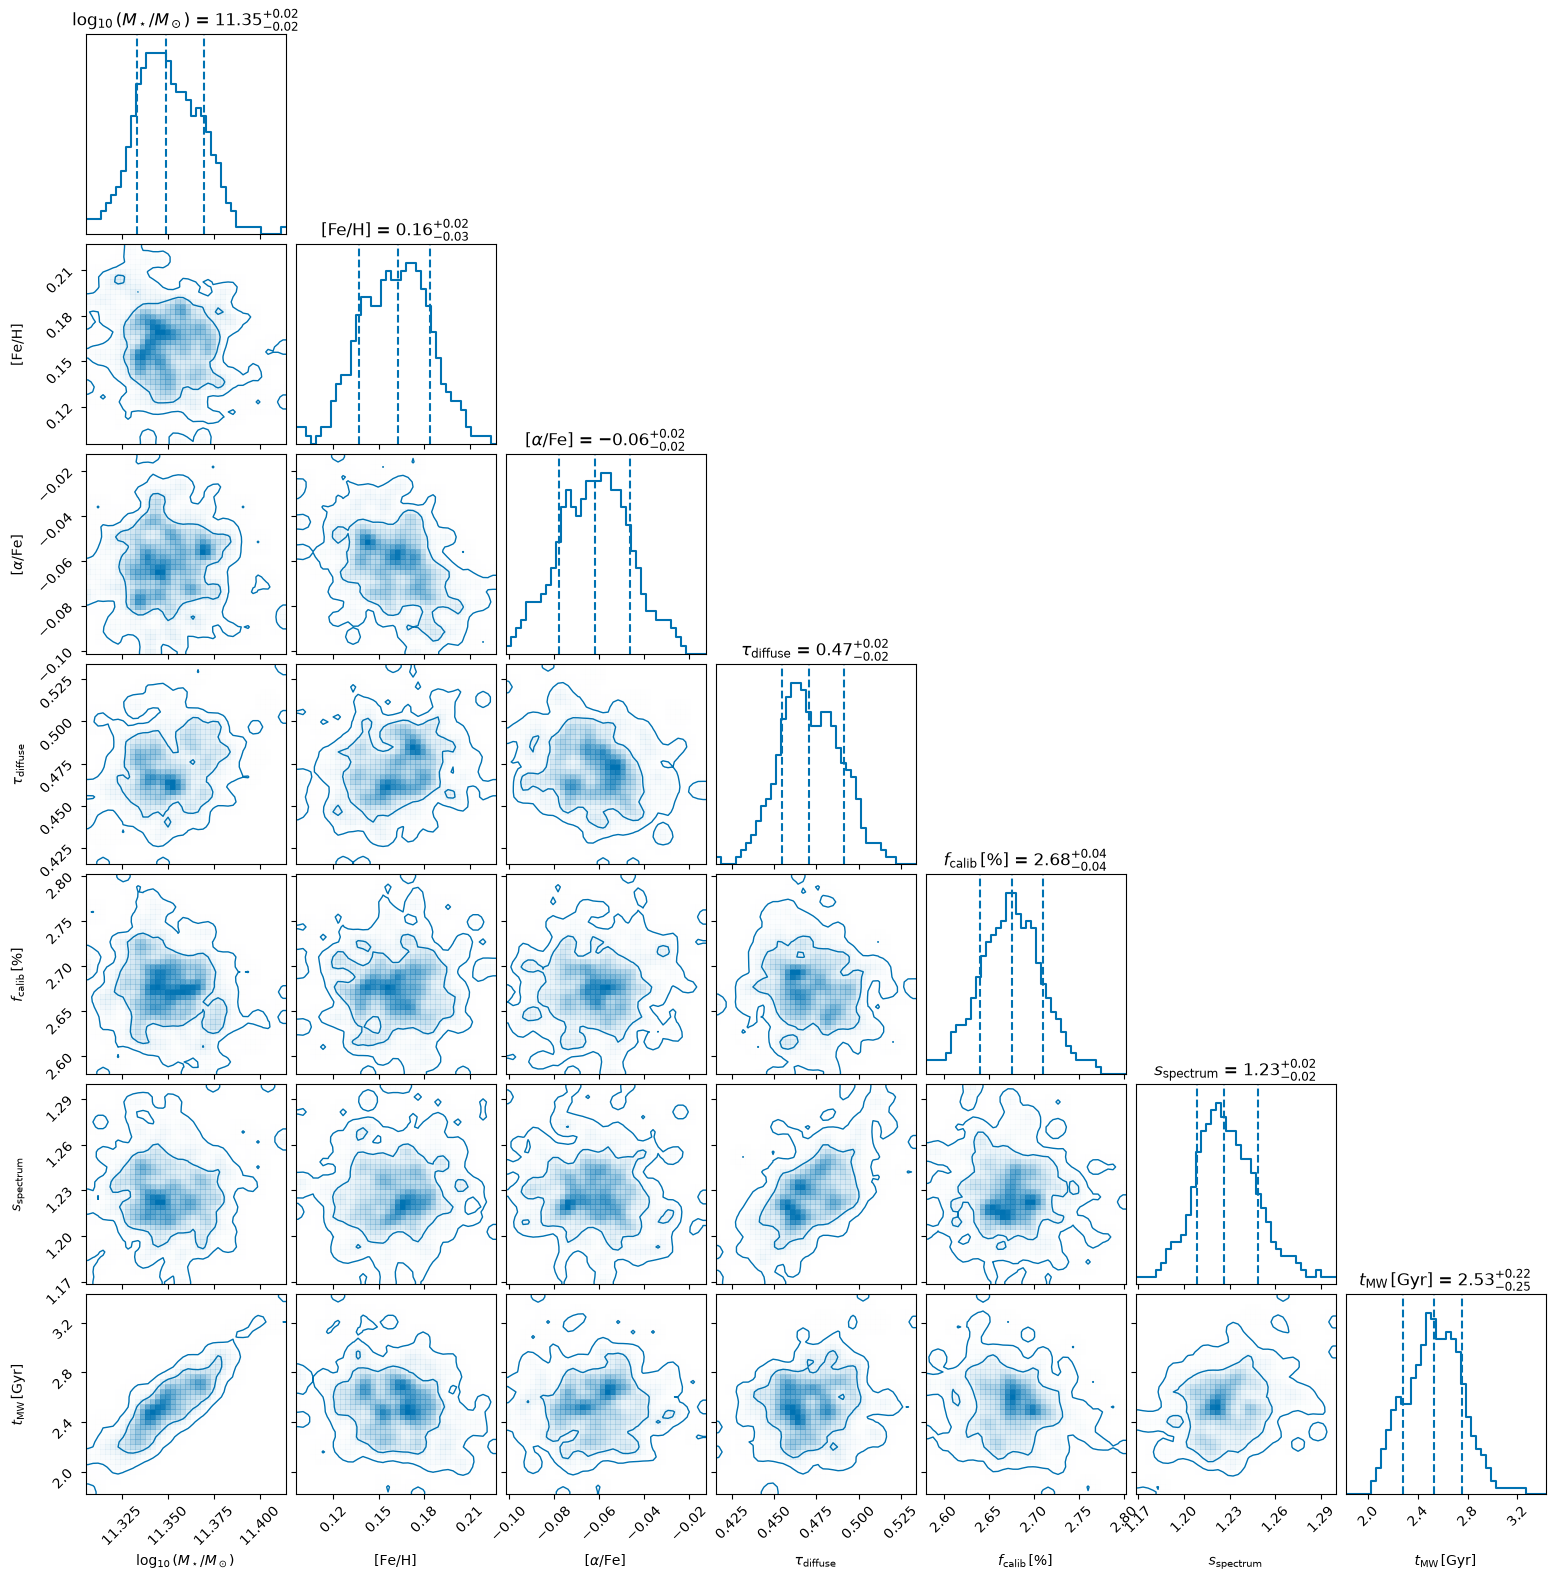

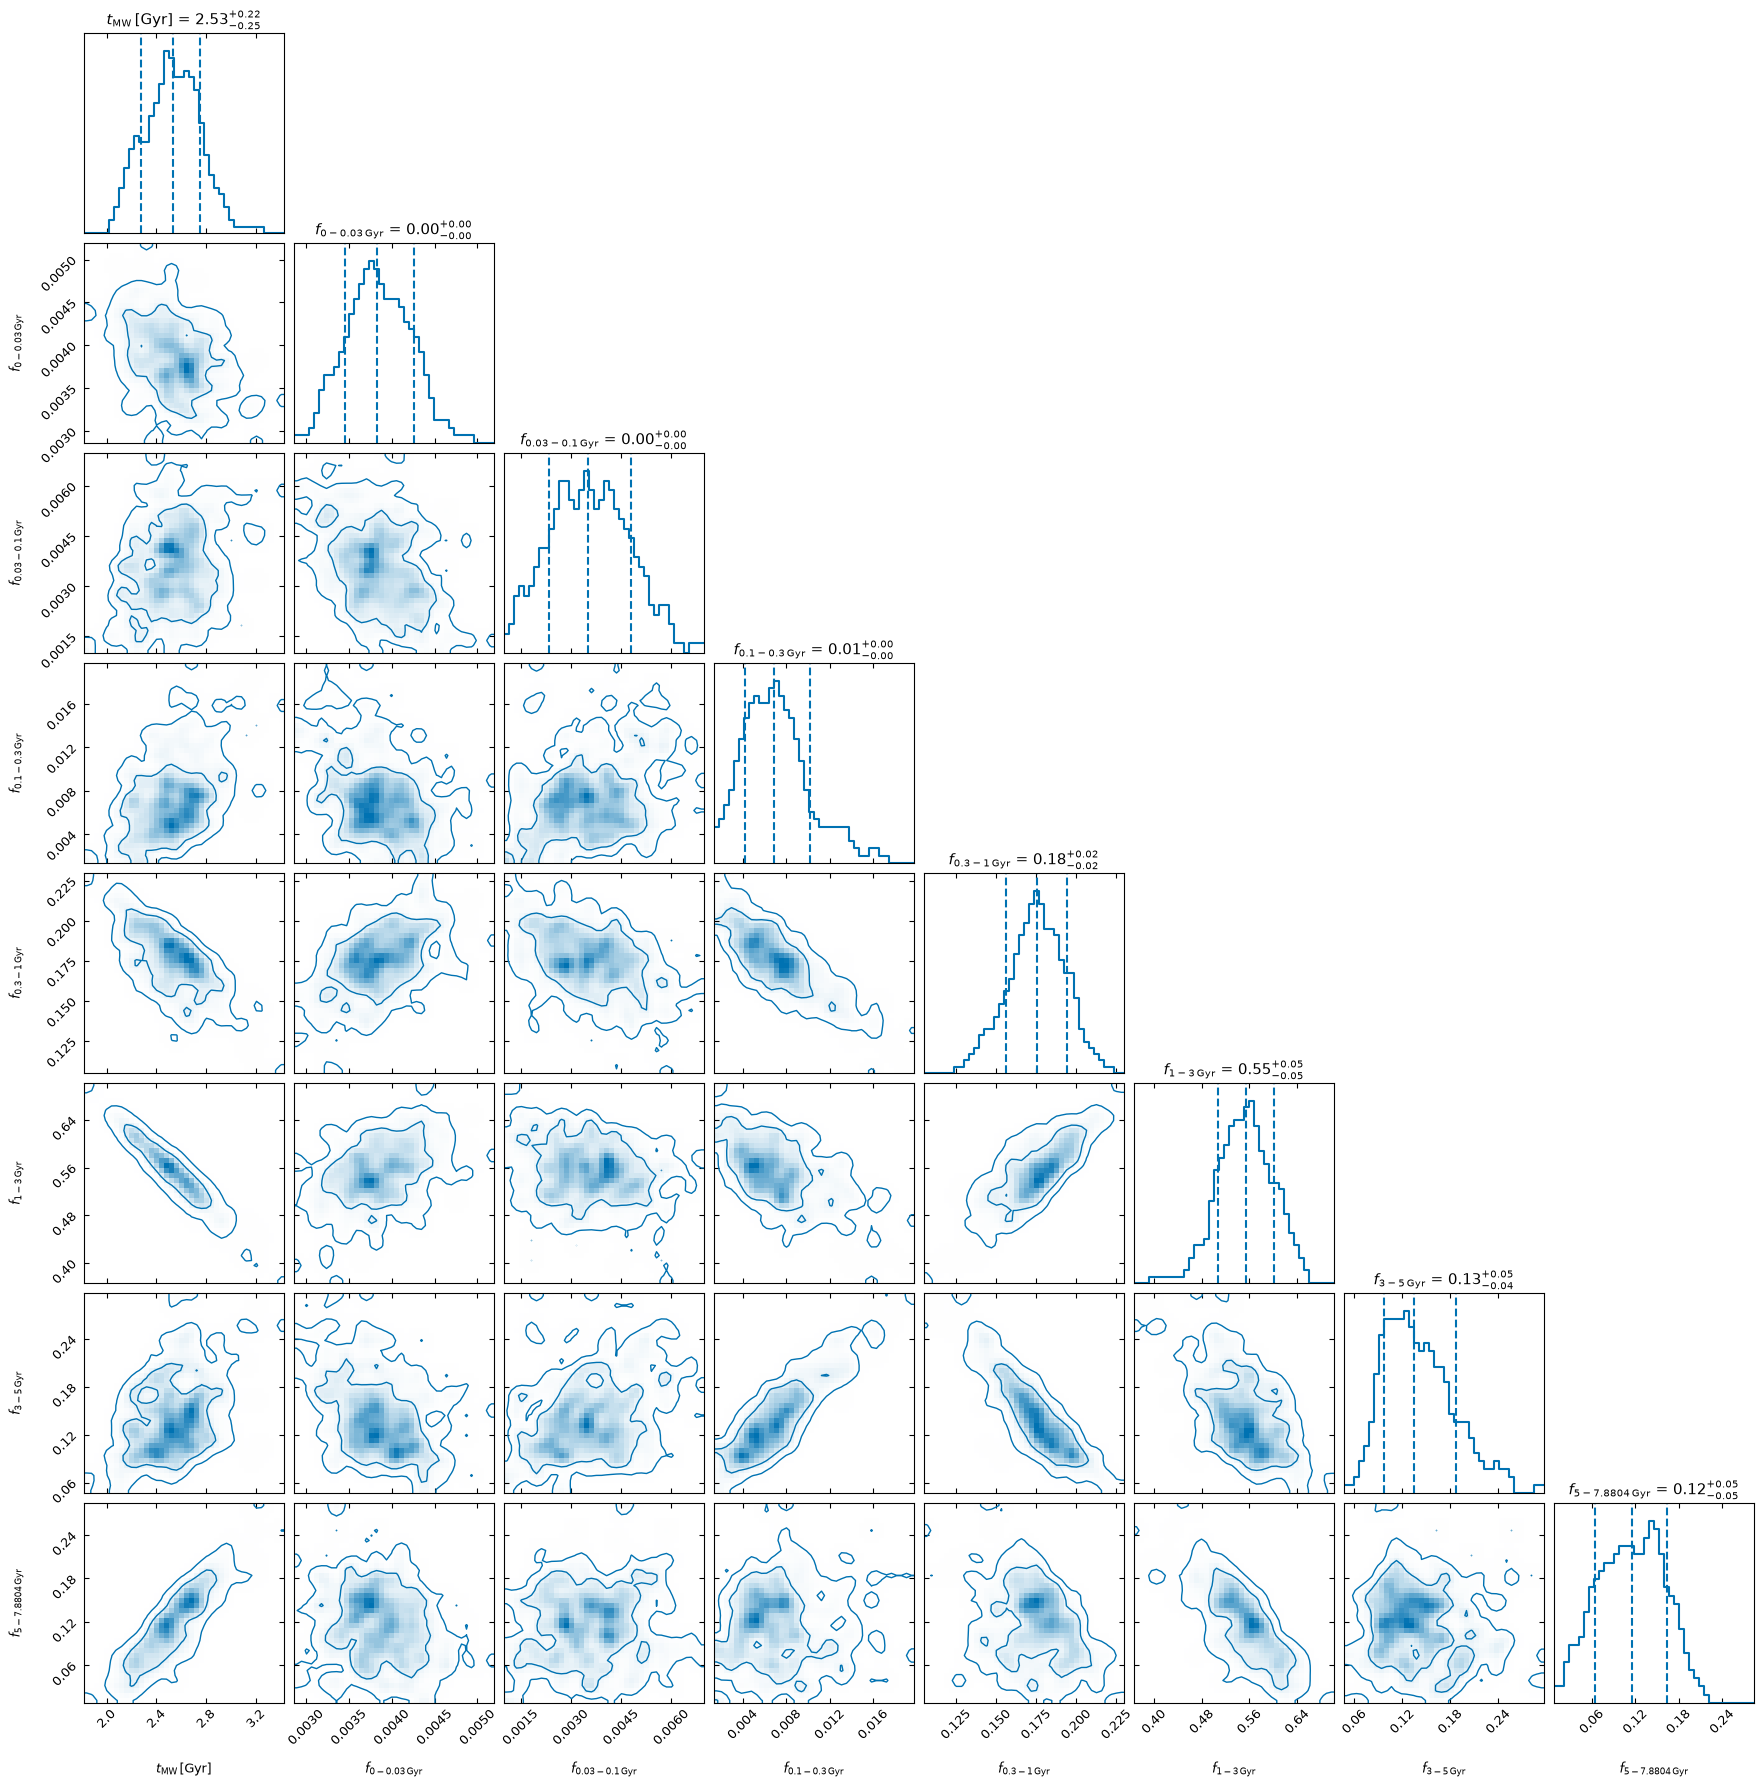

,parameter,q16,q50,q84,unit
0,logsfr_rat...,0.166000,0.450870,0.755606,dex
1,logsfr_rat...,0.074399,0.312391,0.617824,dex
2,logsfr_rat...,-0.288220,-0.068451,0.164352,dex
3,logsfr_rat...,-1.424455,-1.144321,-0.801864,dex
4,logsfr_rat...,0.442541,0.760297,1.003201,dex
5,logsfr_rat...,-0.073058,0.207329,0.626378,dex
6,logsfr_rat...,-0.086349,0.190693,0.878990,dex
7,logmass,11.333095,11.348802,11.369674,log10(M_sun)
8,[Fe/H],0.136964,0.162477,0.183586,dex
9,afe,-0.077806,-0.061679,-0.046293,dex


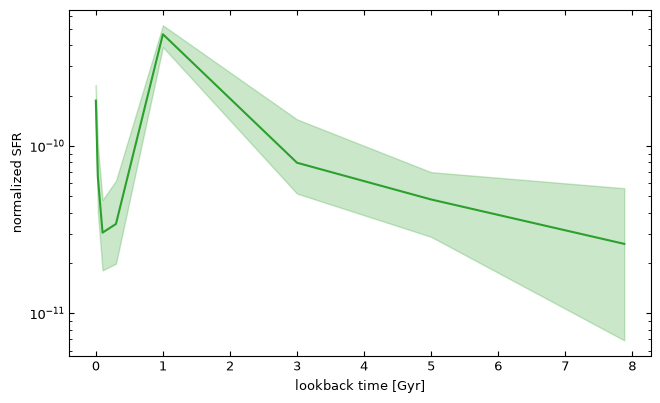

joint redshift fixed at 0.6037
spectrum normalization fitted with spectrum_scaling
joint fit status: diagnostics passed
saved derived outputs: /workspace/cosmic-chronometers-jwst/results/fit-accuracy-knobs/new_default_rep1/172669-M5_172669/ceridwen_derived_outputs.h5


In [14]:
posterior_row_count = len(joint_posterior["logsfr_ratios"])
posterior_indices = np.linspace(
    0,
    posterior_row_count - 1,
    min(400, posterior_row_count),
    dtype=int,
)
selected_posterior = {
    name: np.asarray(values)[posterior_indices]
    for name, values in joint_posterior.items()
}
selected_row_count = len(posterior_indices)


def scalar_draws(samples, name):
    return np.asarray(samples[name]).reshape(selected_row_count)


def derived_sfh(samples):
    histories = []
    for ratios in samples["logsfr_ratios"]:
        history = np.asarray(
            logsfr_ratios_to_sfh(
                ratios,
                sfh_times_yr=lookback_template * 1e9,
            )
        )
        histories.append(history)
    histories = np.asarray(histories)
    interval_durations_yr = np.diff(lookback_template) * 1e9
    interval_masses = (
        0.5 * (histories[:, :-1] + histories[:, 1:]) * interval_durations_yr
    )
    total_formed_mass = interval_masses.sum(axis=1)
    mass_fractions = interval_masses / total_formed_mass[:, None]
    interval_ages_gyr = 0.5 * (lookback_template[:-1] + lookback_template[1:])
    mass_weighted_age = (
        interval_masses * interval_ages_gyr
    ).sum(axis=1) / total_formed_mass
    return histories, interval_masses, mass_fractions, mass_weighted_age


joint_histories, joint_interval_masses, joint_mass_fractions, joint_ages = (
    derived_sfh(selected_posterior)
)
# Grid Z is log10 of the iron abundance relative to Z_sun = 0.0185
# (ceridwen/scripts_afe/build_afe_hr_grid.py), so [Fe/H] = Z + FEH_OFFSET.
FEH_OFFSET = 1.7328283
direct_draws = {
    name: scalar_draws(selected_posterior, name)
    for name in ["logmass", "Z", "afe", "diffuse_tau_kc"]
}
calibration_percent = None
spectrum_scaling = None
if FIT_MODE == "full_spectrum":
    calibration_percent = 100.0 * np.exp(
        scalar_draws(selected_posterior, "log_f_calib")
    )
    spectrum_scaling = scalar_draws(selected_posterior, "spectrum_scaling")
# Redshift as a velocity offset from the catalogue: dv = c (z - z_cat) / (1 + z_cat).
zred_offset_kms = None
sigma_smooth_draws = None
if FREE_ZRED_KMS > 0:
    zred_offset_kms = (
        C_KMS * (scalar_draws(selected_posterior, "zred") - z_catalog) / (1.0 + z_catalog)
    )
if FREE_SIGMA_FRAC > 0:
    sigma_smooth_draws = scalar_draws(selected_posterior, "sigma_smooth")
aligned_arrays = [
    *direct_draws.values(),
    *([] if calibration_percent is None else [calibration_percent]),
    *([] if spectrum_scaling is None else [spectrum_scaling]),
    *([] if zred_offset_kms is None else [zred_offset_kms]),
    *([] if sigma_smooth_draws is None else [sigma_smooth_draws]),
    joint_histories,
    joint_interval_masses,
    joint_mass_fractions,
    joint_ages,
]
assert all(values.shape[0] == selected_row_count for values in aligned_arrays)
assert all(np.all(np.isfinite(values)) for values in aligned_arrays)
assert np.all(joint_mass_fractions >= -1e-12)
assert np.allclose(joint_mass_fractions.sum(axis=1), 1.0, rtol=0.0, atol=1e-10)

physical_columns = [
    direct_draws["logmass"],
    direct_draws["Z"] + FEH_OFFSET,
    direct_draws["afe"],
    direct_draws["diffuse_tau_kc"],
]
physical_labels = [
    r"$\log_{10}(M_\star/M_\odot)$",
    r"$[\mathrm{Fe}/\mathrm{H}]$",
    r"$[\alpha/\mathrm{Fe}]$",
    r"$\tau_{\mathrm{diffuse}}$",
]
physical_ranges = [
    joint_bounds["logmass"],
    tuple(np.asarray(joint_bounds["Z"]) + FEH_OFFSET),
    joint_bounds["afe"],
    joint_bounds["diffuse_tau_kc"],
]
if calibration_percent is not None:
    physical_columns.append(calibration_percent)
    physical_labels.append(r"$f_{\mathrm{calib}}\,[\%]$")
    physical_ranges.append(
        tuple(100.0 * np.exp(joint_bounds["log_f_calib"]))
    )
    physical_columns.append(spectrum_scaling)
    physical_labels.append(r"$s_{\mathrm{spectrum}}$")
    physical_ranges.append(joint_bounds["spectrum_scaling"])
if zred_offset_kms is not None:
    physical_columns.append(zred_offset_kms)
    physical_labels.append(r"$\Delta v_z\,[\mathrm{km\,s^{-1}}]$")
    physical_ranges.append((-3.0 * FREE_ZRED_KMS, 3.0 * FREE_ZRED_KMS))
if sigma_smooth_draws is not None:
    physical_columns.append(sigma_smooth_draws)
    physical_labels.append(r"$\sigma_\star\,[\mathrm{km\,s^{-1}}]$")
    physical_ranges.append(joint_bounds["sigma_smooth"])
physical_columns.append(joint_ages)
physical_labels.append(r"$t_{\mathrm{MW}}\,[\mathrm{Gyr}]$")
physical_ranges.append((0.0, universe_age))
physical_corner = np.column_stack(physical_columns)
CORNER_STYLE = {
    "bins": 40,
    "color": "#0072B2",
    "smooth": 1.2,
    "smooth1d": 1.0,
    "plot_datapoints": False,
    "plot_density": True,
    "plot_contours": True,
    "fill_contours": False,
    "hist_kwargs": {"linewidth": 1.5},
    "contour_kwargs": {"linewidths": 1.0},
}

physical_figure = corner.corner(
    physical_corner,
    labels=physical_labels,
    range=physical_ranges if RUN_PROFILE == "quick" else None,
    quantiles=[0.16, 0.50, 0.84],
    title_quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    levels=(0.68, 0.95),
    **CORNER_STYLE,
)
plt.show()

age_mass_fraction_corner = np.column_stack(
    [joint_ages, joint_mass_fractions]
)
mass_fraction_labels = [
    rf"$f_{{{start:g}-{stop:g}\,\mathrm{{Gyr}}}}$"
    for start, stop in pairwise(lookback_template)
]
age_mass_fraction_figure = corner.corner(
    age_mass_fraction_corner,
    labels=[r"$t_{\mathrm{MW}}\,[\mathrm{Gyr}]$", *mass_fraction_labels],
    range=(
        [(0.0, universe_age)]
        + [(0.0, 1.0)] * joint_mass_fractions.shape[1]
        if RUN_PROFILE == "quick"
        else None
    ),
    quantiles=[0.16, 0.50, 0.84],
    title_quantiles=[0.16, 0.50, 0.84],
    show_titles=True,
    levels=(0.68, 0.95),
    **CORNER_STYLE,
)
plt.show()

summary_rows = []
for component in range(N_RATIOS):
    q16, q50, q84 = np.percentile(
        np.asarray(selected_posterior["logsfr_ratios"])[:, component],
        [16, 50, 84],
    )
    summary_rows.append(
        {"parameter": f"logsfr_ratios[{component}]", "q16": q16, "q50": q50, "q84": q84}
    )
for parameter in ["logmass", "Z", "afe", "diffuse_tau_kc"]:
    q16, q50, q84 = np.percentile(
        direct_draws[parameter],
        [16, 50, 84],
    )
    summary_rows.append(
        {
            "parameter": parameter,
            "q16": q16,
            "q50": q50,
            "q84": q84,
        }
    )
if calibration_percent is not None:
    q16, q50, q84 = np.percentile(
        scalar_draws(selected_posterior, "log_f_calib"), [16, 50, 84]
    )
    summary_rows.append(
        {"parameter": "log_f_calib", "q16": q16, "q50": q50, "q84": q84}
    )
    q16, q50, q84 = np.percentile(
        calibration_percent,
        [16, 50, 84],
    )
    summary_rows.append(
        {
            "parameter": "calibration floor [%]",
            "q16": q16,
            "q50": q50,
            "q84": q84,
        }
    )
    q16, q50, q84 = np.percentile(spectrum_scaling, [16, 50, 84])
    summary_rows.append(
        {
            "parameter": "spectrum_scaling",
            "q16": q16,
            "q50": q50,
            "q84": q84,
        }
    )
    if calibration_coefficients is not None:
        for index, name in enumerate(coefficient_table["coefficient"]):
            q16, q50, q84 = np.percentile(calibration_coefficients[:, index], [16, 50, 84])
            summary_rows.append(
                {"parameter": f"calibration {name}", "q16": q16, "q50": q50, "q84": q84}
            )
if zred_offset_kms is not None:
    q16, q50, q84 = np.percentile(scalar_draws(selected_posterior, "zred"), [16, 50, 84])
    summary_rows.append({"parameter": "zred", "q16": q16, "q50": q50, "q84": q84})
    q16, q50, q84 = np.percentile(zred_offset_kms, [16, 50, 84])
    summary_rows.append(
        {"parameter": "redshift offset [km/s]", "q16": q16, "q50": q50, "q84": q84}
    )
if sigma_smooth_draws is not None:
    q16, q50, q84 = np.percentile(sigma_smooth_draws, [16, 50, 84])
    summary_rows.append(
        {"parameter": "sigma_smooth", "q16": q16, "q50": q50, "q84": q84}
    )
q16, q50, q84 = np.percentile(joint_ages, [16, 50, 84])
summary_rows.append(
    {
        "parameter": "mass-weighted age [Gyr]",
        "q16": q16,
        "q50": q50,
        "q84": q84,
    }
)
summary = pd.DataFrame(summary_rows)
summary_units = {
    "logmass": "log10(M_sun)",
    "Z": "log10 iron abundance; [Fe/H] = Z + 1.7328283",
    "afe": "dex",
    "diffuse_tau_kc": "dimensionless",
    "log_f_calib": "natural log fraction",
    "calibration floor [%]": "percent",
    "spectrum_scaling": "dimensionless",
    "zred": "dimensionless",
    "redshift offset [km/s]": "km/s",
    "sigma_smooth": "km/s",
    "mass-weighted age [Gyr]": "Gyr",
}
summary["unit"] = [
    "dex"
    if name.startswith("logsfr_ratios")
    else "dimensionless"
    if name.startswith("calibration a_")
    else summary_units[name]
    for name in summary["parameter"]
]
summary_display = summary.copy()
z_row = summary_display["parameter"] == "Z"
summary_display.loc[z_row, ["q16", "q50", "q84"]] += FEH_OFFSET
summary_display.loc[z_row, ["parameter", "unit"]] = ["[Fe/H]", "dex"]
display(summary_display)

sfh_q16, sfh_q50, sfh_q84 = np.percentile(
    joint_histories, [16, 50, 84], axis=0
)
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(lookback_template, sfh_q50, color="tab:green")
ax.fill_between(
    lookback_template,
    sfh_q16,
    sfh_q84,
    color="tab:green",
    alpha=0.25,
)
ax.set(
    yscale="log",
    xlabel="lookback time [Gyr]",
    ylabel="normalized SFR",
)
plt.show()

if zred_offset_kms is not None:
    print(f"joint redshift offset: {np.median(zred_offset_kms):+.1f} km/s from catalogue {z_catalog:.4f}")
else:
    print(f"joint redshift fixed at {z_catalog:.4f}")
if sigma_smooth_draws is not None:
    print(f"spectrum sigma*: {np.median(sigma_smooth_draws):.1f} km/s (catalogue {sigma_star:.1f})")
print("spectrum normalization fitted with spectrum_scaling")
print(f"joint fit status: {joint_status}")

derived_path = RESULT_DIR / "ceridwen_derived_outputs.h5"
with h5py.File(derived_path, "w") as derived_file:
    string_dtype = h5py.string_dtype(encoding="utf-8")
    derived_file.attrs["fit_mode"] = FIT_MODE
    derived_file.attrs["target_id"] = TARGET_ID
    derived_file.attrs["object_id"] = OBJECT_ID
    derived_file.attrs["manifest_index"] = MANIFEST_INDEX
    derived_file.attrs["redshift"] = z_catalog
    derived_file.attrs["sigma_star_kms"] = sigma_star
    derived_file.attrs["free_zred_kms"] = FREE_ZRED_KMS
    derived_file.attrs["free_sigma_frac"] = FREE_SIGMA_FRAC
    derived_file.attrs["catalogue_sn"] = float(galaxy["SN"])
    derived_file.attrs["has_4000a_coverage"] = has_4000a_coverage
    derived_file.attrs["random_seed"] = SEED
    derived_file.attrs["parameter_block"] = model_parameter_block_text
    derived_file.attrs["spectrum_pixels"] = SPECTRUM_PIXELS
    derived_file.attrs["feature_window_kms"] = FEATURE_WINDOW_KMS
    derived_file.attrs["feature_downweight"] = feature_downweight
    derived_file.attrs["mock_seed"] = MOCK_SEED
    derived_file.attrs["mock_tilt"] = MOCK_TILT
    derived_file.attrs["mock_snr_scale"] = MOCK_SNR_SCALE
    derived_file.attrs["photometry_source"] = PHOTOMETRY_SOURCE
    derived_file.attrs["calibration_order"] = CALIBRATION_ORDER
    if MOCK_TRUTH is not None:
        truth_group = derived_file.create_group("mock_truth")
        for key, value in MOCK_TRUTH.items():
            truth_group.create_dataset(key, data=np.asarray(value))
    derived_file.attrs["wall_time_s"] = joint_result.wall_time_s
    derived_file.attrs["n_likelihood_calls"] = (
        joint_result.n_likelihood_calls
    )
    for setting, value in joint_settings.items():
        derived_file.attrs[setting] = value

    summary_group = derived_file.create_group("summary")
    summary_group.create_dataset(
        "parameter",
        data=np.asarray(summary["parameter"], dtype=object),
        dtype=string_dtype,
    )
    summary_group.create_dataset(
        "unit",
        data=np.asarray(summary["unit"], dtype=object),
        dtype=string_dtype,
    )
    for column in ["q16", "q50", "q84"]:
        summary_group.create_dataset(column, data=summary[column].to_numpy())

    sfh_group = derived_file.create_group("sfh")
    sfh_group.create_dataset("lookback_time_gyr", data=lookback_template)
    sfh_group.create_dataset("normalized_sfr_draws", data=joint_histories)
    sfh_group.create_dataset("normalized_sfr_q16", data=sfh_q16)
    sfh_group.create_dataset("normalized_sfr_q50", data=sfh_q50)
    sfh_group.create_dataset("normalized_sfr_q84", data=sfh_q84)
    sfh_group.create_dataset("mass_fraction_draws", data=joint_mass_fractions)
    mass_fraction_q16, mass_fraction_q50, mass_fraction_q84 = np.percentile(
        joint_mass_fractions, [16, 50, 84], axis=0
    )
    sfh_group.create_dataset("mass_fraction_q16", data=mass_fraction_q16)
    sfh_group.create_dataset("mass_fraction_q50", data=mass_fraction_q50)
    sfh_group.create_dataset("mass_fraction_q84", data=mass_fraction_q84)
    sfh_group.create_dataset("mass_weighted_age_gyr", data=joint_ages)

    diagnostics_group = derived_file.create_group("diagnostics")
    diagnostics_group.attrs["log_evidence"] = joint_result.log_evidence
    diagnostics_group.attrs["log_evidence_err"] = joint_result.log_evidence_err
    diagnostics_group.attrs["posterior_weight_ess"] = joint_weight_ess
    diagnostics_group.attrs["status"] = joint_status
    diagnostics_group.attrs["passed"] = joint_diagnostics_passed

    if FIT_MODE == "full_spectrum":
        photometry_group = derived_file.create_group("photometry")
        photometry_group.create_dataset(
            "filters", data=np.asarray(FILTER_NAMES, dtype=object), dtype=string_dtype
        )
        photometry_group.create_dataset("wavelength", data=filter_wave_eff)
        photometry_group.create_dataset("observed", data=phot_flux)
        photometry_group.create_dataset("uncertainty", data=phot_uncertainty)
        photometry_group.create_dataset("mask", data=phot_fit_mask)
        photometry_group.create_dataset("posterior_q16", data=phot_q16)
        photometry_group.create_dataset("posterior_q50", data=phot_q50)
        photometry_group.create_dataset("posterior_q84", data=phot_q84)
        photometry_group.create_dataset(
            "pull", data=(phot_flux - phot_q50) / phot_uncertainty
        )

        spectrum_group = derived_file.create_group("spectrum")
        spectrum_group.create_dataset("wavelength", data=spectrum_wave)
        spectrum_group.create_dataset("observed", data=spectrum_flux)
        spectrum_group.create_dataset("uncertainty", data=spectrum_uncertainty)
        spectrum_group.create_dataset(
            "effective_uncertainty", data=effective_spec_uncertainty
        )
        spectrum_group.create_dataset("mask", data=spectrum_mask)
        if feature_mask is not None:
            spectrum_group.create_dataset("feature_mask", data=feature_mask)
        spectrum_group.create_dataset("posterior_q16", data=spec_q16)
        spectrum_group.create_dataset("posterior_q50", data=spec_q50)
        spectrum_group.create_dataset("posterior_q84", data=spec_q84)
        spectrum_group.create_dataset("pull", data=spectrum_plot_pull)
        if calibration_polynomial is not None:
            calibration_group = derived_file.create_group("calibration")
            calibration_group.attrs["order"] = CALIBRATION_ORDER
            calibration_group.attrs["fit_constant"] = False
            calibration_group.attrs["prior_sigma"] = CALIBRATION_PRIOR_SIGMA
            calibration_group.attrs["marginalized"] = True
            calibration_group.attrs["basis"] = (
                "P(x) = 1 + sum_n a_n T_n(x), Chebyshev, x in [-1, 1] over fitted pixels"
            )
            calibration_group.create_dataset("x", data=np.asarray(calibration_polynomial.x))
            calibration_group.create_dataset("coefficient_draws", data=calibration_coefficients)
            calibration_group.create_dataset("spectrum_scaling_draws", data=scaling_draws)
            calibration_group.create_dataset("polynomial_q16", data=poly_q16)
            calibration_group.create_dataset("polynomial_q50", data=poly_q50)
            calibration_group.create_dataset("polynomial_q84", data=poly_q84)
        diagnostics_group.attrs["photometry_chi2"] = phot_chi2
        diagnostics_group.attrs["spectrum_chi2"] = spectrum_chi2
        diagnostics_group.attrs["joint_chi2"] = joint_chi2
        diagnostics_group.attrs["photometry_ndof"] = phot_obs.ndof
        diagnostics_group.attrs["spectrum_ndof"] = spectrum_obs.ndof
        diagnostics_group.attrs["joint_ndof"] = joint_points
    if FIT_MODE == "stellar_indices":
        index_group = derived_file.create_group("stellar_indices")
        index_group.create_dataset(
            "names",
            data=np.asarray(stellar_indices_obs.index_names, dtype=object),
            dtype=string_dtype,
        )
        index_group.create_dataset(
            "units",
            data=np.asarray(stellar_indices_obs.index_units, dtype=object),
            dtype=string_dtype,
        )
        index_group.create_dataset("observed", data=index_values)
        index_group.create_dataset(
            "uncertainty", data=index_uncertainties
        )
        index_group.create_dataset("mask", data=index_mask)
        index_group.create_dataset("posterior_q16", data=index_q16)
        index_group.create_dataset("posterior_median", data=index_q50)
        index_group.create_dataset("posterior_q84", data=index_q84)
        index_group.create_dataset("pull", data=index_pull)
with h5py.File(derived_path, "r") as derived_file:
    assert {"summary", "sfh", "diagnostics"}.issubset(derived_file.keys())
print(f"saved derived outputs: {derived_path}")

## Interpretation

- Treat each fit as one weighted posterior result.
- Full mode fits the spectrum normalization directly.
- Index mode ignores unavailable index covariance.
- Do not propagate this age into cosmology yet.
